# Data Preprocessing
## Import Libraries

In [1]:
# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots within the notebook
%matplotlib inline

# Improve plot appearance
sns.set_style("whitegrid")


# Ignore Warning Messages

import warnings
warnings.filterwarnings("ignore")

# Scikit-learn Preprocessing

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Feature Selection

from boruta import BorutaPy

# Machine Learning Algorithms

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from xgboost import XGBClassifier

# Model Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

# Cross Validation

from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

# Explainable AI

import shap

# Save Models

import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Load dataset
df = pd.read_csv("CKD_NHANES_2021_2023.csv")

In [3]:
df.head() # Display first five rows

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,...,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,...,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,...,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,...,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,...,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1


In [4]:
df.tail() # Display last five rows

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,...,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
11928,142306.0,9.0,Male,Other Hispanic,NaN,2.01,15.4,25.3,128.0,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
11929,142307.0,49.0,Female,Non-Hispanic Black,5.0,NaN,NaN,NaN,143.8,127.0,...,6.31,6.78,1.0,2.0,1.0,1.0,3.0,91.64,No CKD,0
11930,142308.0,50.0,Male,Other Hispanic,4.0,1.95,26.4,79.3,173.3,106.0,...,6.98,4.03,2.0,NaN,NaN,2.0,NaN,NaN,Unknown,1
11931,142309.0,40.0,Male,Other Hispanic,4.0,3.11,25.5,81.9,179.1,127.0,...,9.27,3.65,2.0,NaN,NaN,2.0,NaN,92.03,No CKD,0
11932,142310.0,80.0,Female,Non-Hispanic White,3.0,5.00,27.6,72.1,161.7,128.0,...,7.15,14.90,2.0,NaN,NaN,1.0,3.0,56.28,Stage 3a (Mild-Moderate),1


In [5]:
# Dataset shape
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 11933
Number of Columns: 29


In [6]:
df.columns # Column names

Index(['participant_id', 'age', 'gender', 'ethnicity', 'education_level',
       'poverty_income_ratio', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic',
       'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen',
       'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid',
       'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio',
       'diabetes_diagnosed', 'insulin_use', 'diabetes_pills', 'ever_smoked',
       'current_smoker', 'egfr', 'ckd_stage', 'ckd_present'],
      dtype='object')

In [7]:
df.info() # Dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            11933 non-null  float64
 1   age                       11933 non-null  float64
 2   gender                    11933 non-null  object 
 3   ethnicity                 11933 non-null  object 
 4   education_level           7794 non-null   float64
 5   poverty_income_ratio      9892 non-null   float64
 6   bmi                       8471 non-null   float64
 7   weight_kg                 8754 non-null   float64
 8   height_cm                 8499 non-null   float64
 9   bp_systolic               7517 non-null   float64
 10  bp_diastolic              7517 non-null   float64
 11  serum_creatinine          6326 non-null   float64
 12  blood_urea_nitrogen       6326 non-null   float64
 13  albumin_serum             6366 non-null   float64
 14  phosph

In [8]:
# Summary Statistics for Numerical Variable

df.describe().T 

,count,mean,std,min,25%,50%,75%,max
participant_id,11933.0,136344.000000,3444.904716,1.303780e+05,133361.0000,136344.00,139327.00,142310.00
age,11933.0,38.317858,25.601990,5.397605e-79,13.0000,37.00,62.00,80.00
education_level,7794.0,3.804978,1.153750,1.000000e+00,3.0000,4.00,5.00,9.00
poverty_income_ratio,9892.0,2.708174,1.670119,5.397605e-79,1.1800,2.50,4.50,5.00
bmi,8471.0,27.246665,8.137781,1.110000e+01,21.6000,26.40,31.70,74.80
weight_kg,8754.0,70.549037,30.389021,2.700000e+00,54.2000,71.70,89.10,248.20
height_cm,8499.0,159.664549,19.864943,7.910000e+01,154.4000,163.60,172.10,200.70
bp_systolic,7517.0,119.288546,18.561052,6.100000e+01,106.0000,117.00,130.00,232.00
bp_diastolic,7517.0,72.748038,11.895572,3.300000e+01,64.0000,72.00,80.00,142.00
serum_creatinine,6326.0,0.872828,0.385498,3.300000e-01,0.7000,0.83,0.98,15.17


In [9]:
# Summary statistics for all columns (Including Categorical Variables)

df.describe(include='all').T 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
participant_id,11933.0,NaN,NaN,NaN,136344.0,3444.904716,130378.0,133361.0,136344.0,139327.0,142310.0
age,11933.0,NaN,NaN,NaN,38.317858,25.60199,0.0,13.0,37.0,62.0,80.0
gender,11933,2,Female,6358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,11933,6,Non-Hispanic White,6217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,7794.0,NaN,NaN,NaN,3.804978,1.15375,1.0,3.0,4.0,5.0,9.0
poverty_income_ratio,9892.0,NaN,NaN,NaN,2.708174,1.670119,0.0,1.18,2.5,4.5,5.0
bmi,8471.0,NaN,NaN,NaN,27.246665,8.137781,11.1,21.6,26.4,31.7,74.8
weight_kg,8754.0,NaN,NaN,NaN,70.549037,30.389021,2.7,54.2,71.7,89.1,248.2
height_cm,8499.0,NaN,NaN,NaN,159.664549,19.864943,79.1,154.4,163.6,172.1,200.7
bp_systolic,7517.0,NaN,NaN,NaN,119.288546,18.561052,61.0,106.0,117.0,130.0,232.0


In [10]:
# Dataset Dimension

print(f"Number of observations : {df.shape[0]}")
print(f"Number of variables    : {df.shape[1]}")

Number of observations : 11933
Number of variables    : 29


In [11]:
# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print(f"Numerical Features   : {len(numerical_columns)}")
print(f"Categorical Features : {len(categorical_columns)}")

Numerical Features   : 26
Categorical Features : 3


In [12]:
print("Numerical Features:")
print(numerical_columns.tolist())

Numerical Features:
['participant_id', 'age', 'education_level', 'poverty_income_ratio', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic', 'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'diabetes_diagnosed', 'insulin_use', 'diabetes_pills', 'ever_smoked', 'current_smoker', 'egfr', 'ckd_present']


In [13]:
print("Categorical Features:")
print(categorical_columns.tolist())

Categorical Features:
['gender', 'ethnicity', 'ckd_stage']


In [14]:
constant_columns = [
    col for col in df.columns
    if df[col].nunique() == 1
]

print("Constant Columns:")
print(constant_columns)

Constant Columns:
[]


In [15]:
unique_values = pd.DataFrame({
    "Feature": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

unique_values.sort_values(by="Unique Values")

,Feature,Unique Values
2,gender,2
22,insulin_use,2
28,ckd_present,2
25,current_smoker,3
23,diabetes_pills,3
21,diabetes_diagnosed,4
24,ever_smoked,4
3,ethnicity,6
4,education_level,6
27,ckd_stage,8


In [16]:
# Missing Values Count

missing_values = df.isnull().sum()

missing_values

participant_id                  0
age                             0
gender                          0
ethnicity                       0
education_level              4139
poverty_income_ratio         2041
bmi                          3462
weight_kg                    3179
height_cm                    3434
bp_systolic                  4416
bp_diastolic                 4416
serum_creatinine             5607
blood_urea_nitrogen          5607
albumin_serum                5567
phosphorus                   5611
bicarbonate                  5608
calcium                      5571
uric_acid                    5604
urine_creatinine             3779
urine_albumin                3780
albumin_creatinine_ratio     3780
diabetes_diagnosed            193
insulin_use                 10852
diabetes_pills               9652
ever_smoked                  3798
current_smoker               8690
egfr                         5607
ckd_stage                       0
ckd_present                     0
dtype: int64

In [17]:
# Missing value percentages

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

missing_df.sort_values(by='Missing Percentage', ascending=False)

,Missing Count,Missing Percentage
insulin_use,10852,90.941088
diabetes_pills,9652,80.884941
current_smoker,8690,72.823263
phosphorus,5611,47.020867
bicarbonate,5608,46.995726
blood_urea_nitrogen,5607,46.987346
serum_creatinine,5607,46.987346
egfr,5607,46.987346
uric_acid,5604,46.962206
calcium,5571,46.685662


In [18]:
# Display only columns containing missing values

missing_df = missing_df[missing_df['Missing Count'] > 0]

missing_df.sort_values(by='Missing Percentage', ascending=False)

,Missing Count,Missing Percentage
insulin_use,10852,90.941088
diabetes_pills,9652,80.884941
current_smoker,8690,72.823263
phosphorus,5611,47.020867
bicarbonate,5608,46.995726
egfr,5607,46.987346
blood_urea_nitrogen,5607,46.987346
serum_creatinine,5607,46.987346
uric_acid,5604,46.962206
calcium,5571,46.685662


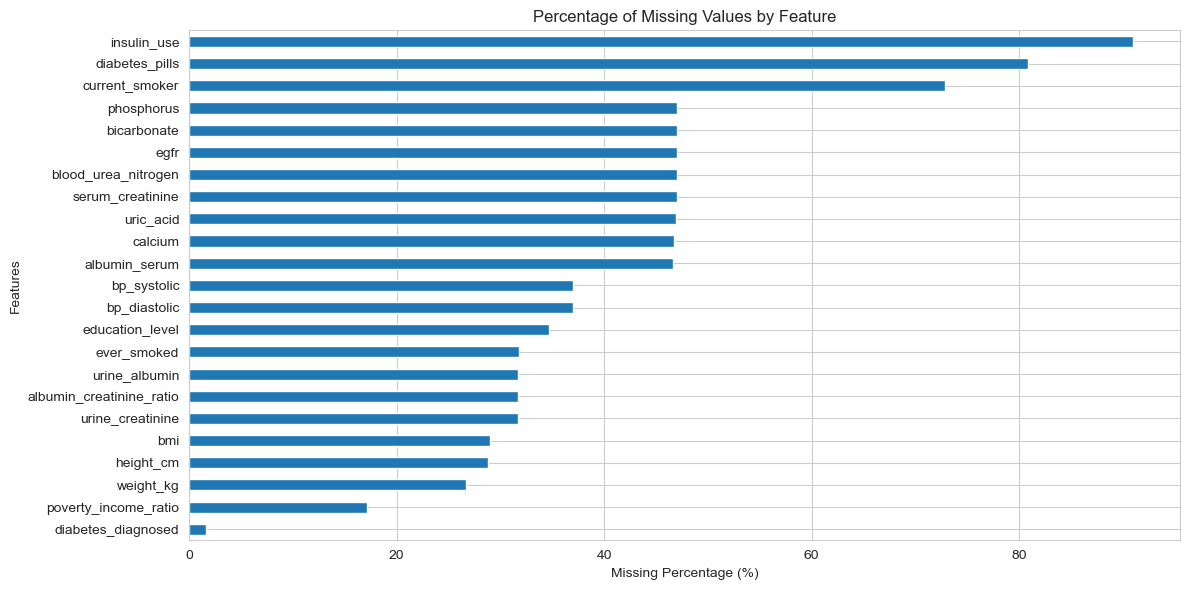

In [19]:
plt.figure(figsize=(12,6))

missing_df['Missing Percentage'].sort_values().plot(kind='barh')

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

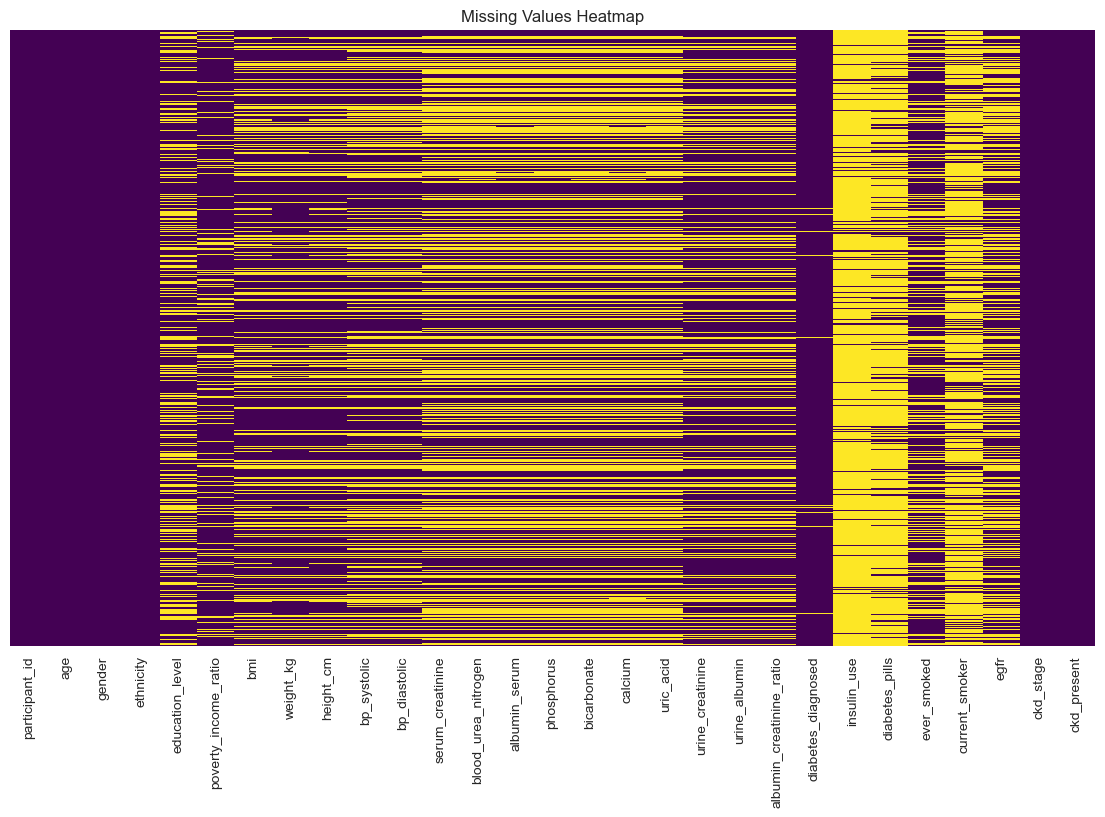

In [20]:
plt.figure(figsize=(14,8))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis',
            yticklabels=False)

plt.title("Missing Values Heatmap")

plt.show()

In [21]:
total_missing = df.isnull().sum().sum()

print(f"Total Missing Values: {total_missing}")

print(f"Percentage Missing: {(total_missing / df.size) * 100:.2f}%")

Total Missing Values: 114393
Percentage Missing: 33.06%


In [22]:
# Check Duplicate Rows

duplicate_rows = df.duplicated().sum()

print(f"Number of Duplicate Rows: {duplicate_rows}")

Number of Duplicate Rows: 0


In [23]:
# Target Variable Distribution

df['ckd_present'].value_counts()

ckd_present
1    8341
0    3592
Name: count, dtype: int64

In [24]:
df['ckd_present'].value_counts(normalize=True) * 100

ckd_present
1    69.898601
0    30.101399
Name: proportion, dtype: float64

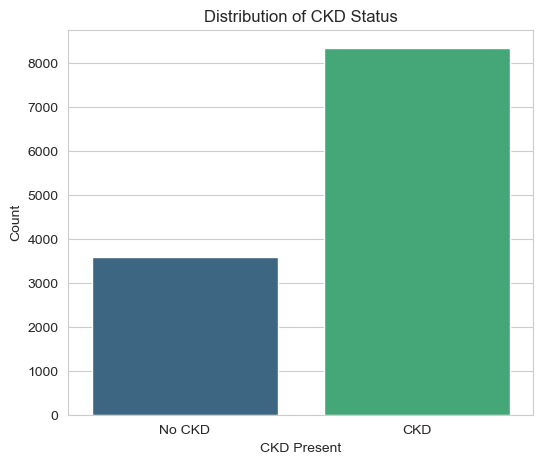

In [25]:
plt.figure(figsize=(6, 5))

sns.countplot(data=df, x='ckd_present', palette='viridis')

plt.title("Distribution of CKD Status")
plt.xlabel("CKD Present")
plt.ylabel("Count")

plt.xticks([0, 1], ["No CKD", "CKD"])

plt.show()

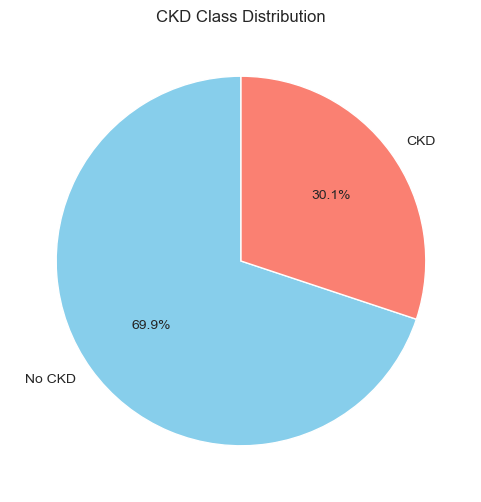

In [26]:
plt.figure(figsize=(6, 6))

df['ckd_present'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['No CKD', 'CKD'],
    startangle=90,
    colors=['skyblue', 'salmon']
)

plt.ylabel("")
plt.title("CKD Class Distribution")

plt.show()

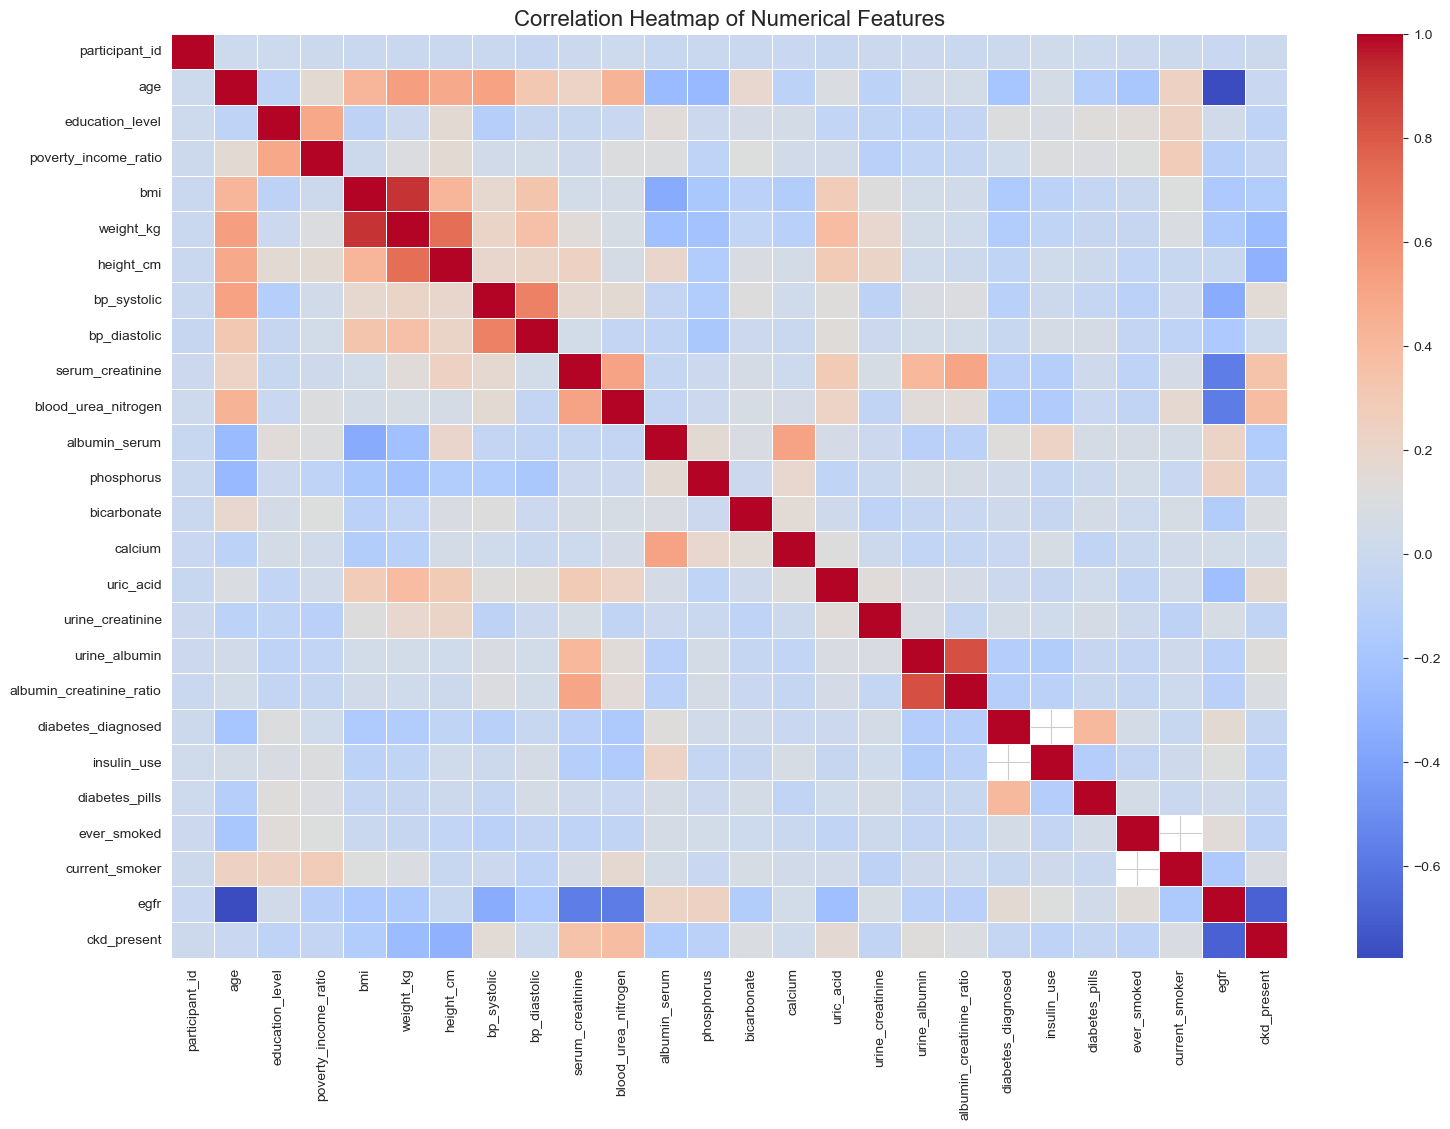

In [27]:
# Correlation Heatmap

plt.figure(figsize=(18, 12))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)

plt.show()

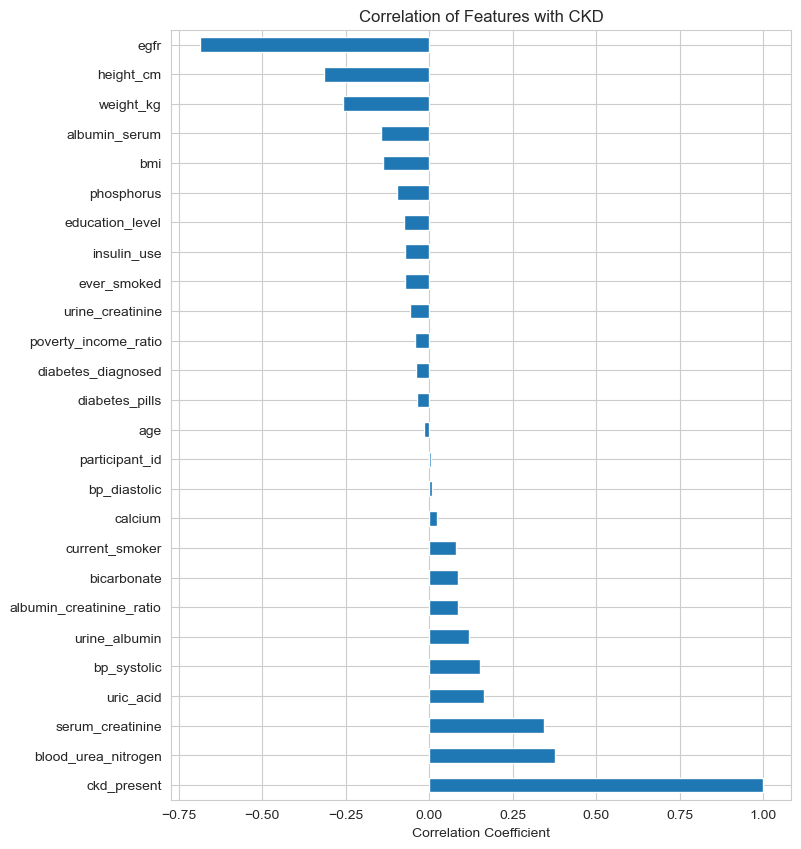

ckd_present                 1.000000
blood_urea_nitrogen         0.376539
serum_creatinine            0.342947
uric_acid                   0.163093
bp_systolic                 0.152682
urine_albumin               0.119813
albumin_creatinine_ratio    0.086244
bicarbonate                 0.085214
current_smoker              0.079362
calcium                     0.022999
bp_diastolic                0.008765
participant_id              0.005938
age                        -0.015352
diabetes_pills             -0.036836
diabetes_diagnosed         -0.039825
poverty_income_ratio       -0.043473
urine_creatinine           -0.056182
ever_smoked                -0.071377
insulin_use                -0.074015
education_level            -0.074249
phosphorus                 -0.095586
bmi                        -0.139227
albumin_serum              -0.143627
weight_kg                  -0.258702
height_cm                  -0.316080
egfr                       -0.687409
Name: ckd_present, dtype: float64


In [28]:
# Correlation with target variable

target_corr = correlation_matrix["ckd_present"].sort_values(ascending=False)

plt.figure(figsize=(8,10))

target_corr.plot(kind="barh")

plt.title("Correlation of Features with CKD")

plt.xlabel("Correlation Coefficient")

plt.show()

print(target_corr)

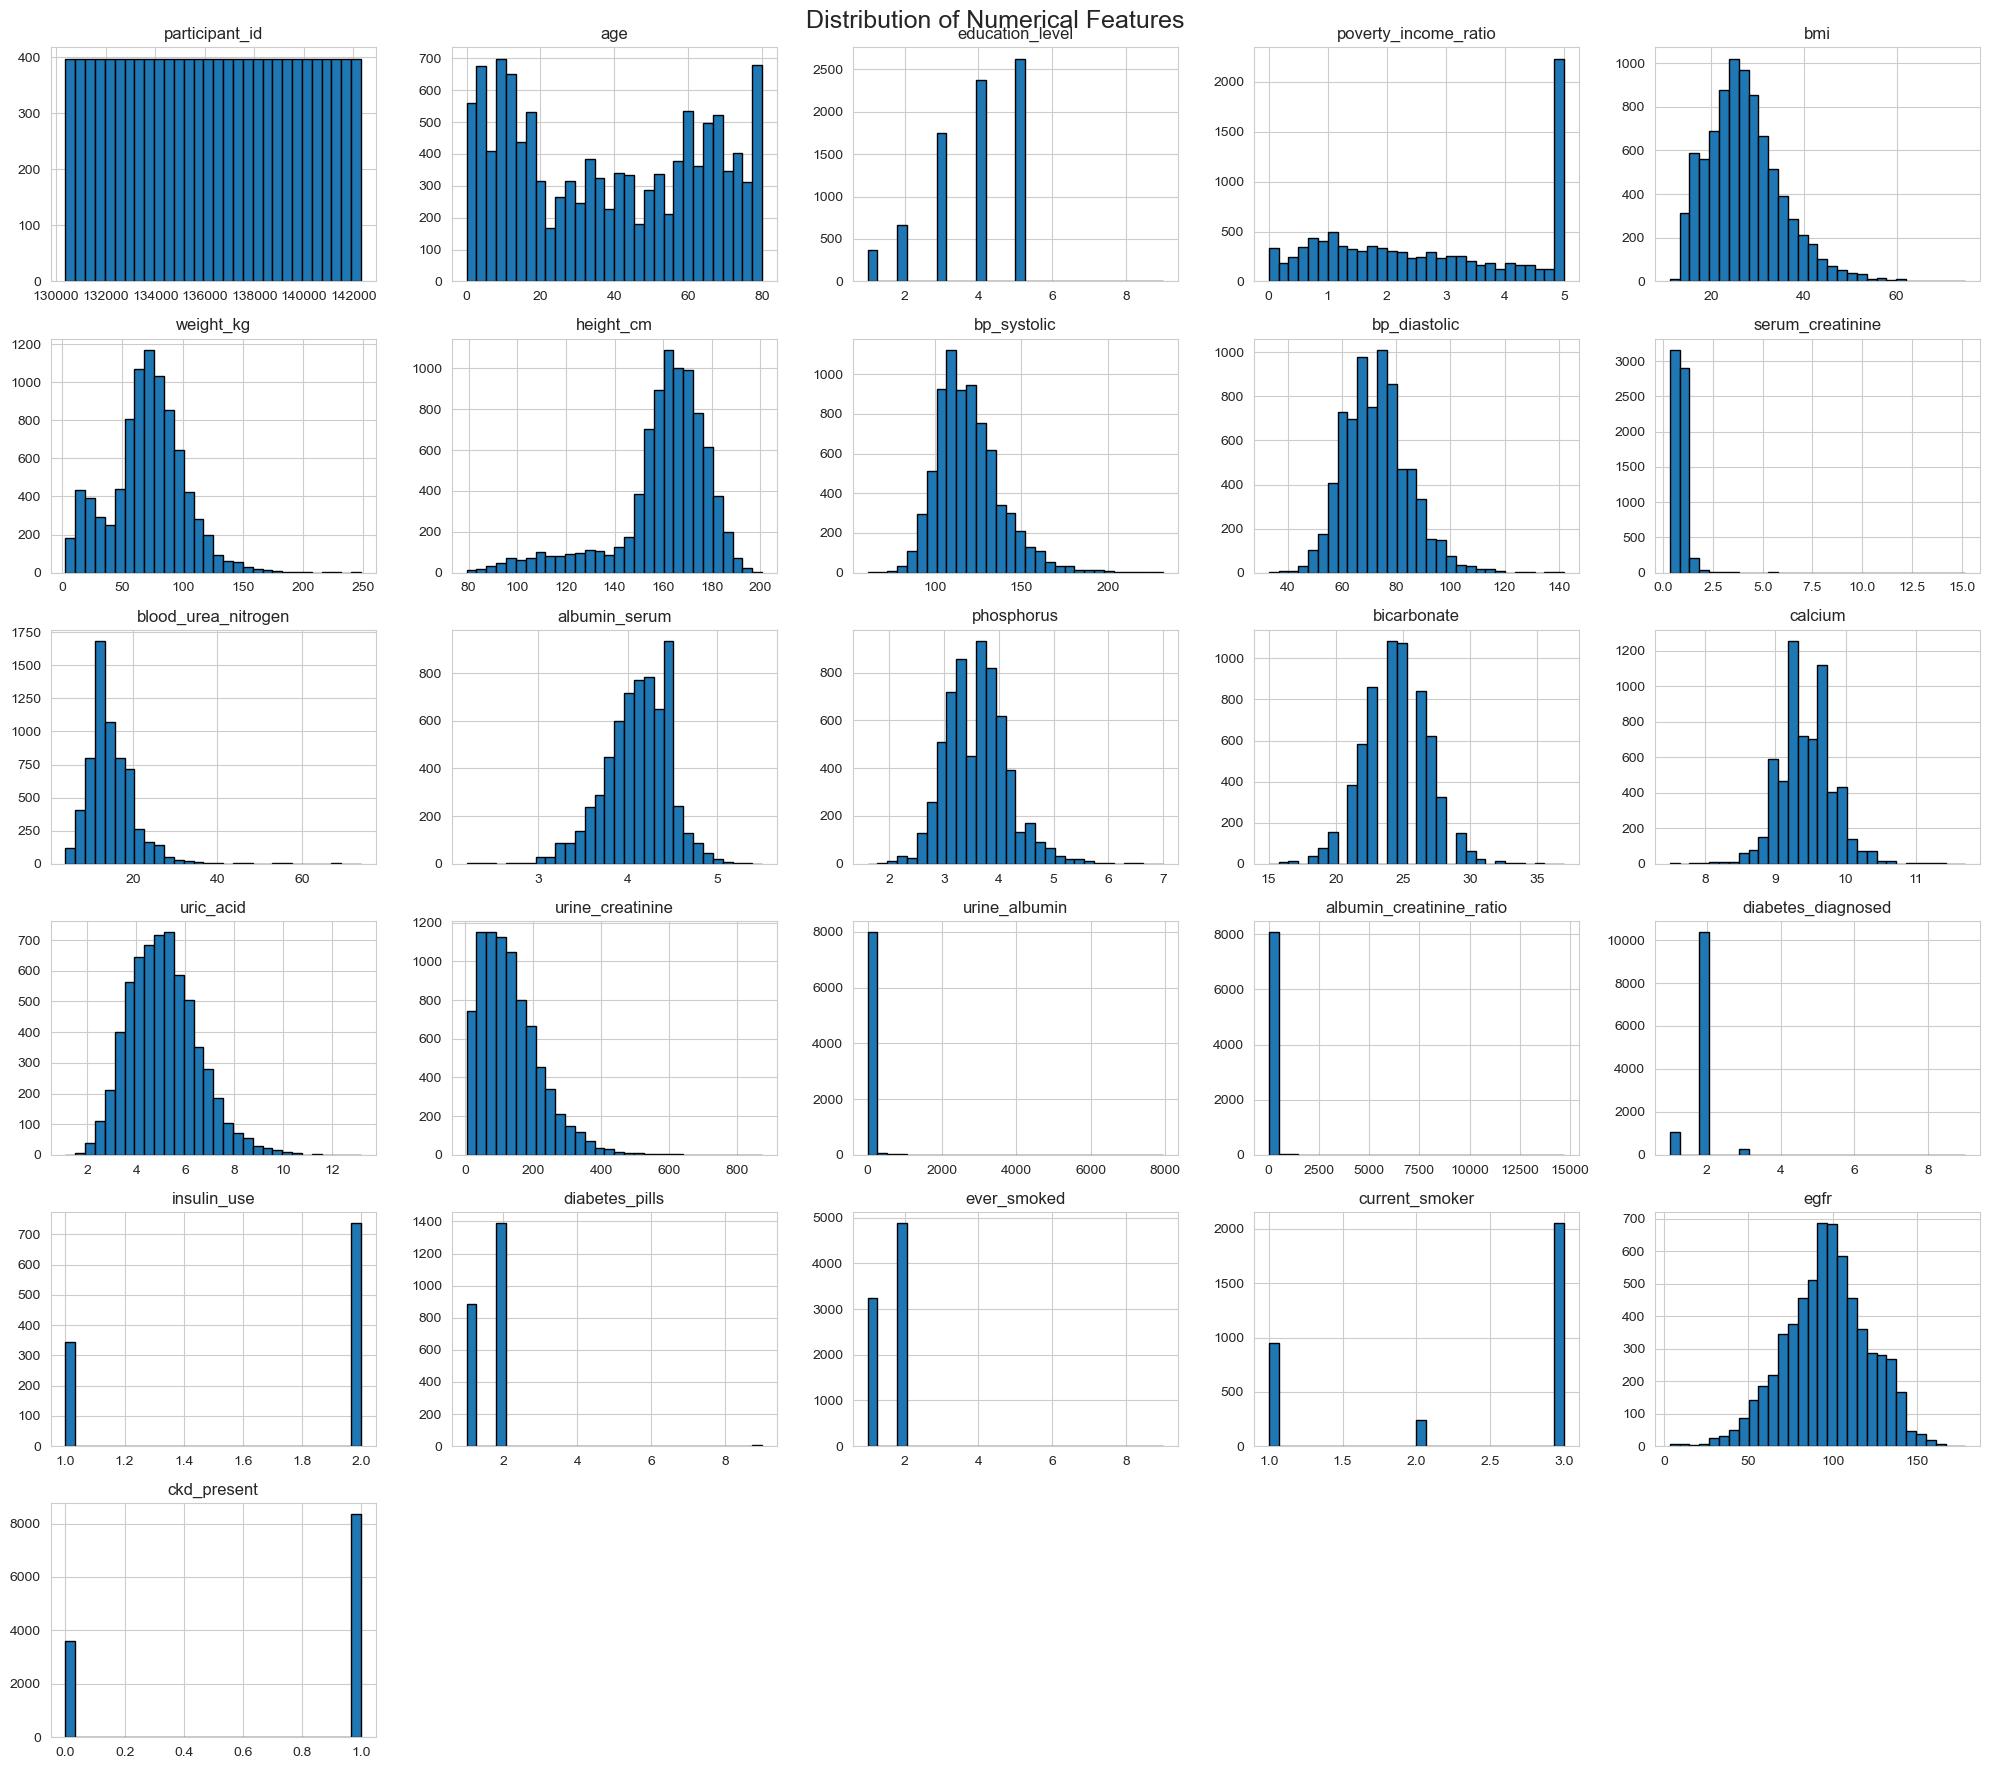

In [29]:
# Histograms

df.hist(
    figsize=(20,18),
    bins=30,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.tight_layout()

plt.show()

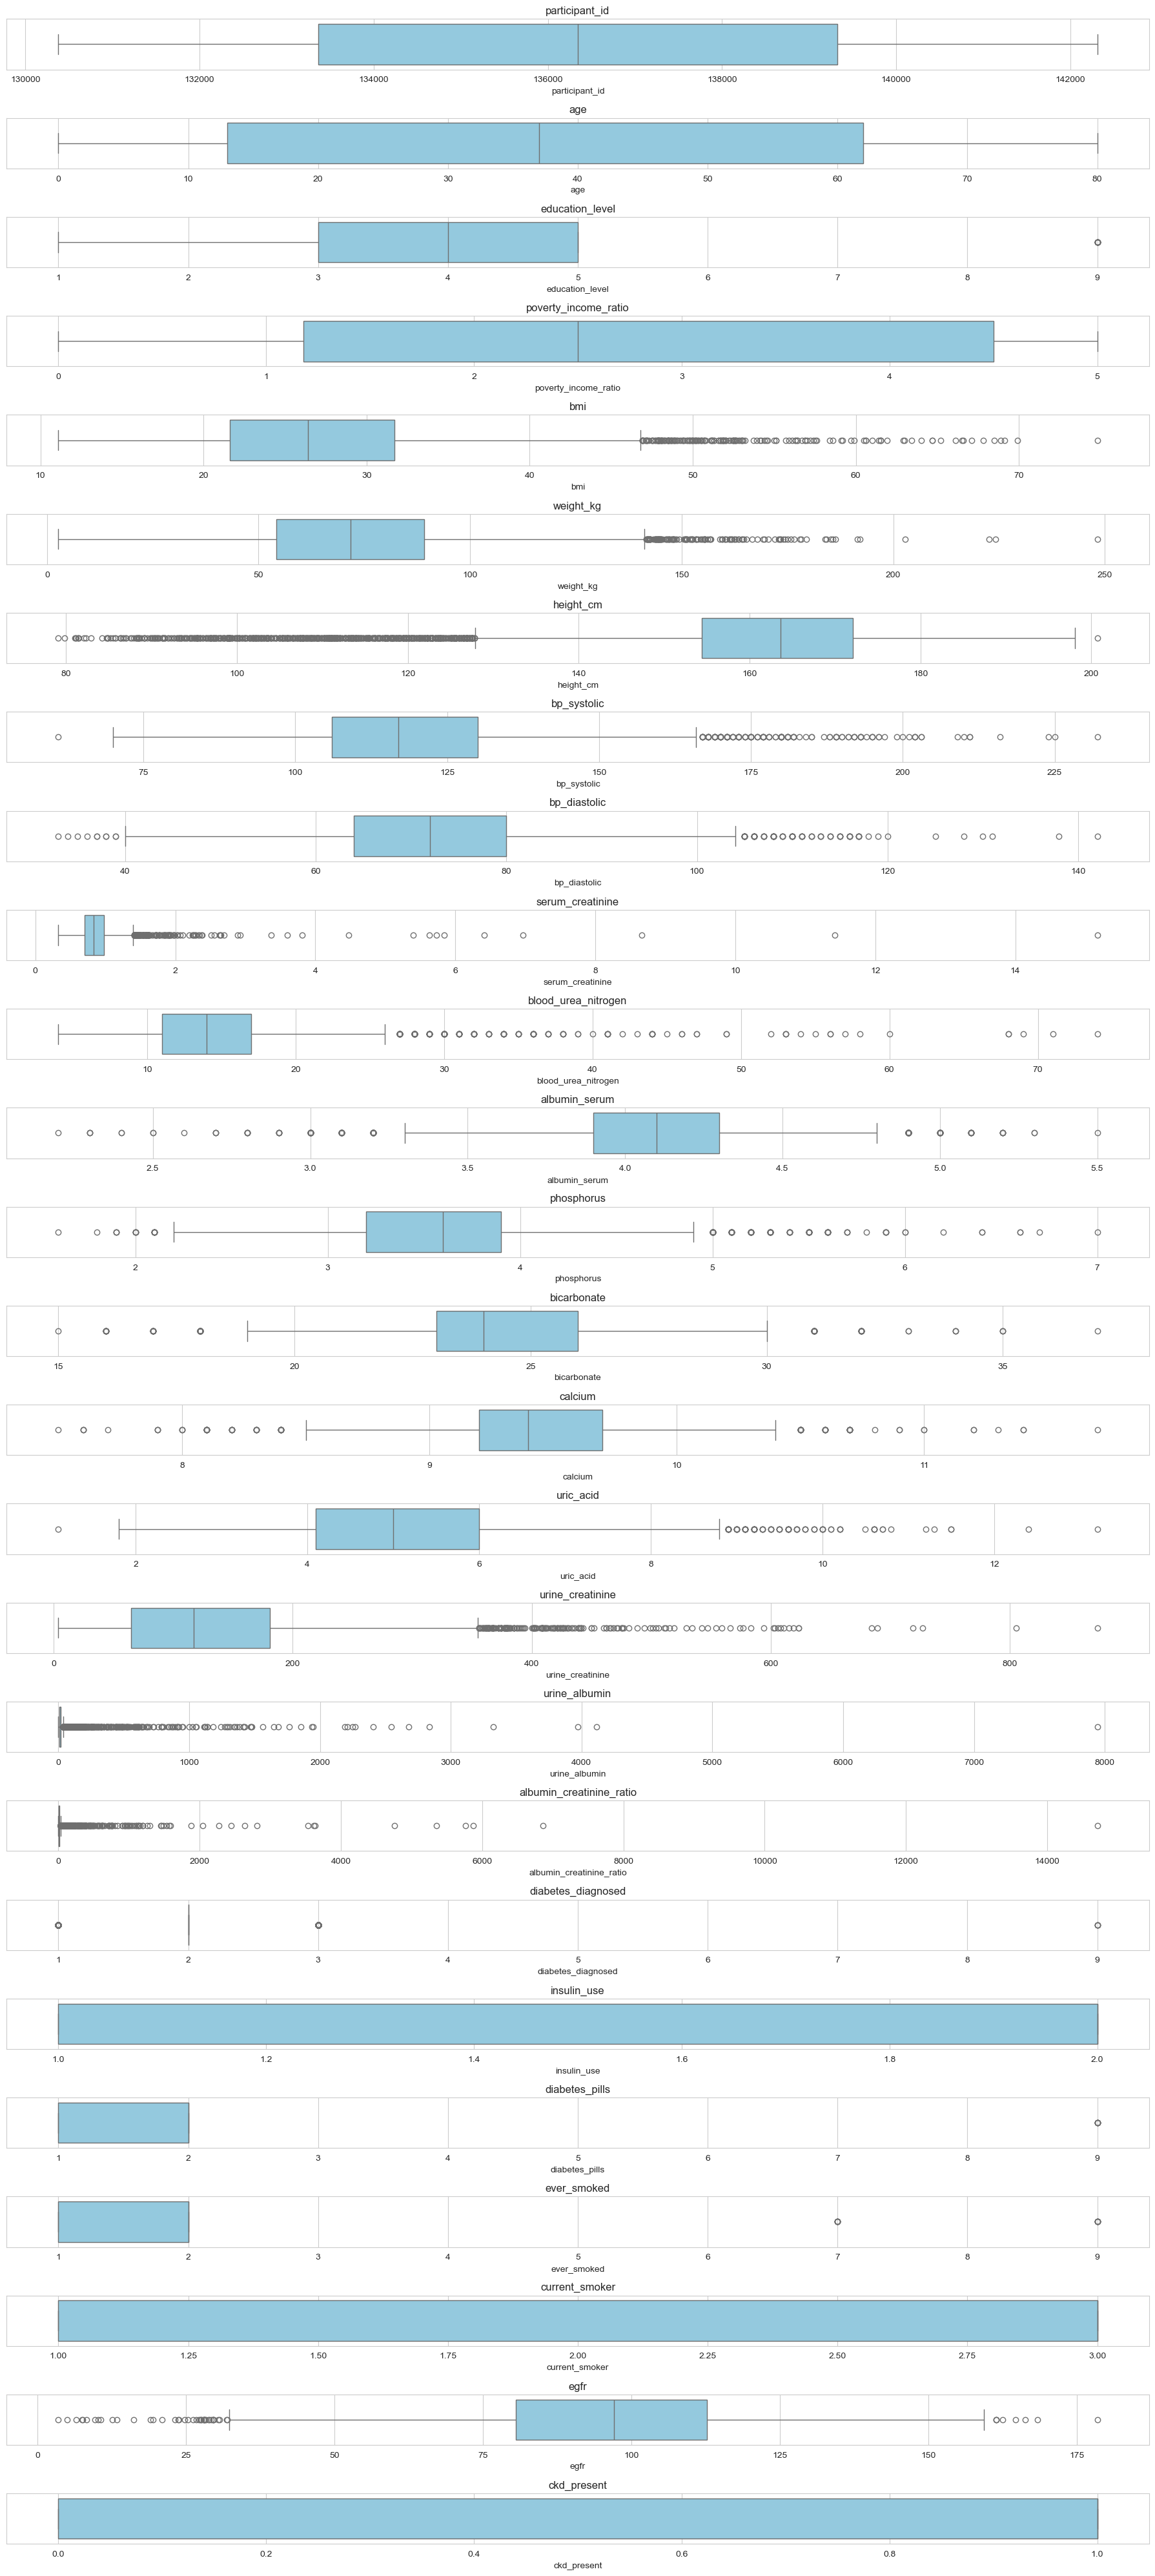

In [30]:
# Boxplots (Outlier detection)

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18, 40))

for i, column in enumerate(numerical_columns):

    plt.subplot(len(numerical_columns), 1, i+1)

    sns.boxplot(
        x=df[column],
        color="skyblue"
    )

    plt.title(column)

plt.tight_layout()

plt.show()

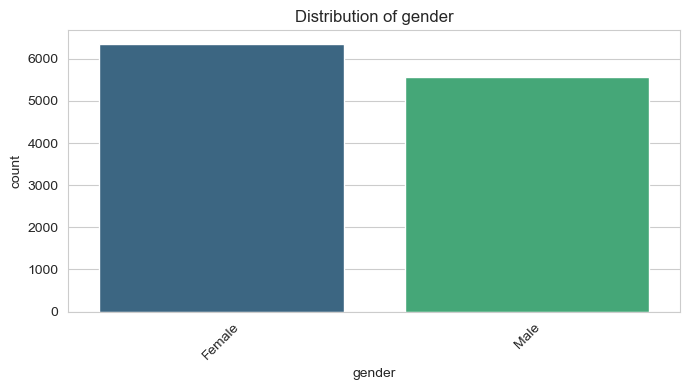

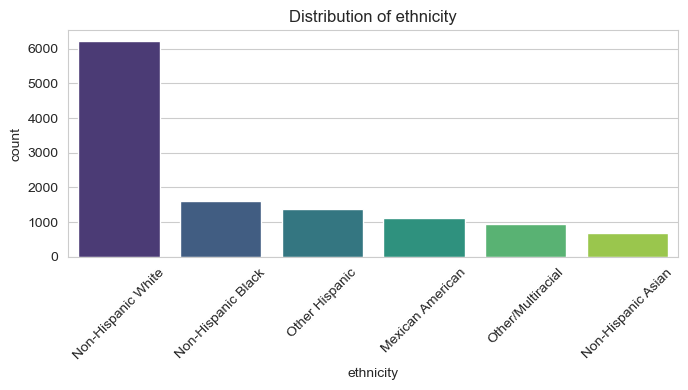

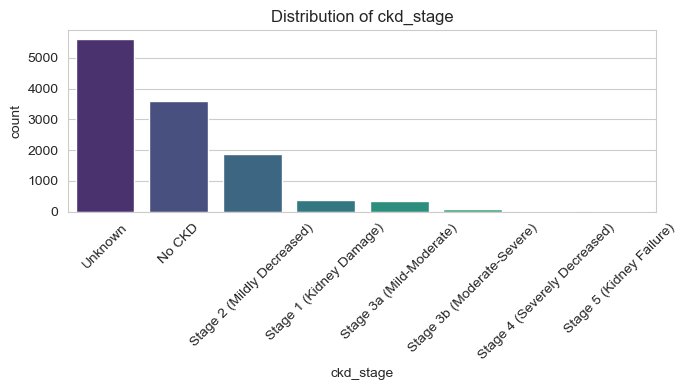

In [31]:
categorical_columns = df.select_dtypes(include=['object']).columns

for column in categorical_columns:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index,
        palette="viridis"
    )

    plt.title(f"Distribution of {column}")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

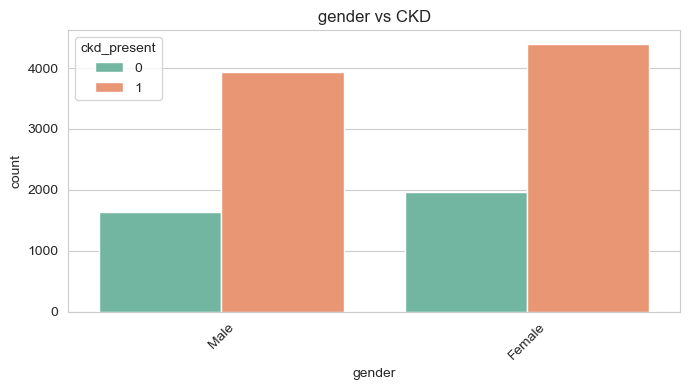

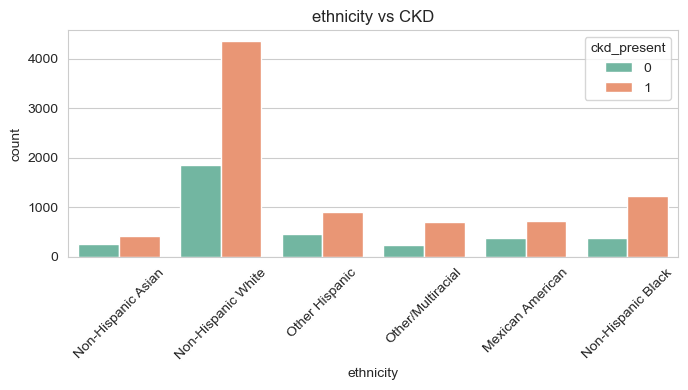

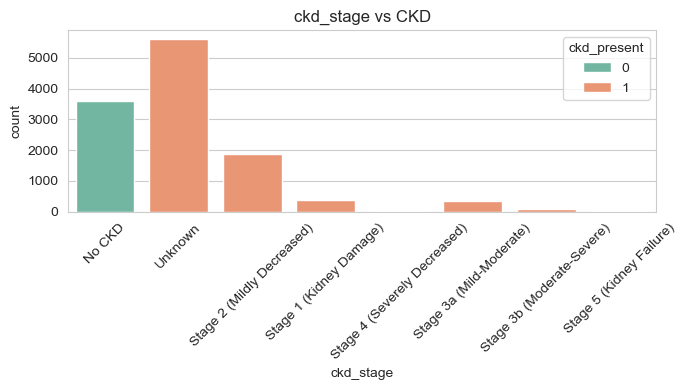

In [32]:
for column in categorical_columns:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=column,
        hue="ckd_present",
        palette="Set2"
    )

    plt.title(f"{column} vs CKD")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

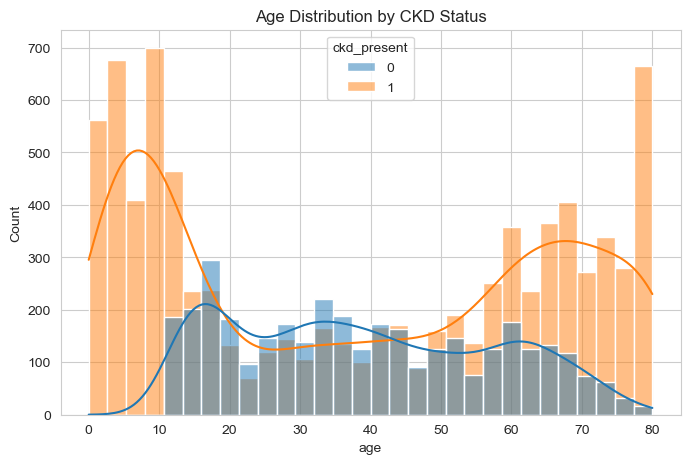

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    hue="ckd_present",
    kde=True,
    bins=30
)

plt.title("Age Distribution by CKD Status")

plt.show()

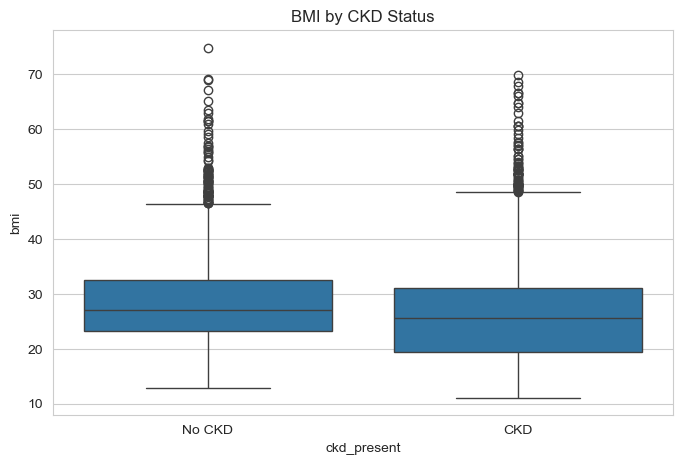

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="ckd_present",
    y="bmi"
)

plt.xticks([0,1],["No CKD","CKD"])

plt.title("BMI by CKD Status")

plt.show()

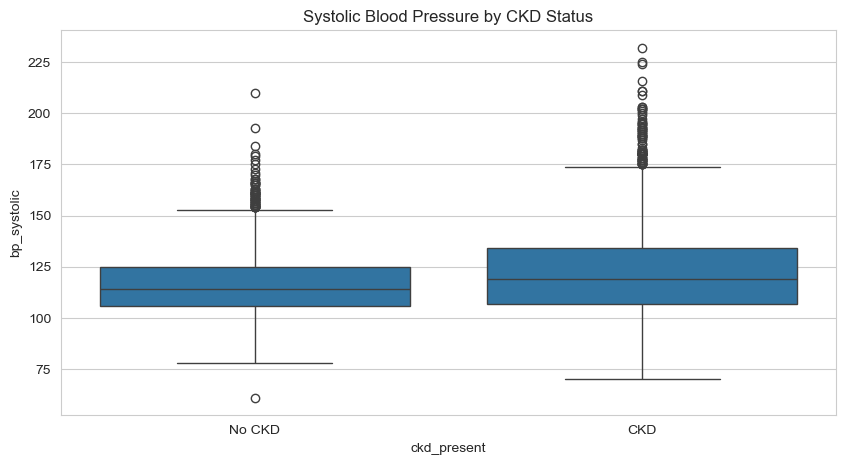

In [35]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="ckd_present",
    y="bp_systolic"
)

plt.xticks([0,1],["No CKD","CKD"])

plt.title("Systolic Blood Pressure by CKD Status")

plt.show()

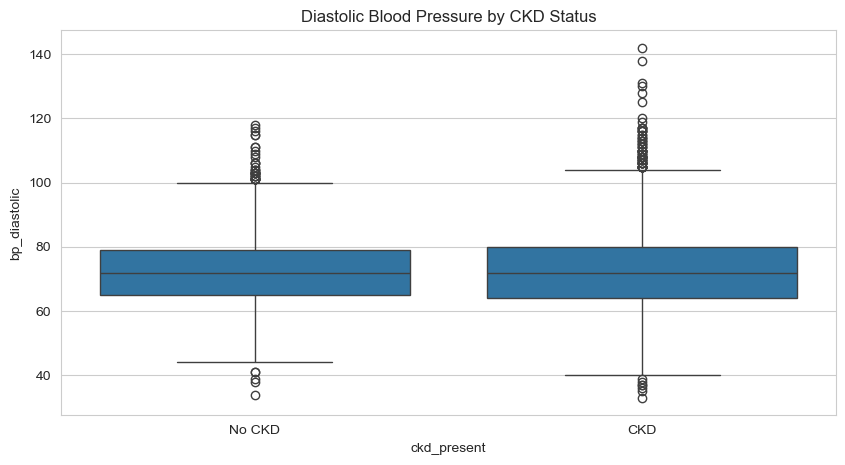

In [36]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="ckd_present",
    y="bp_diastolic"
)

plt.xticks([0,1],["No CKD","CKD"])

plt.title("Diastolic Blood Pressure by CKD Status")

plt.show()

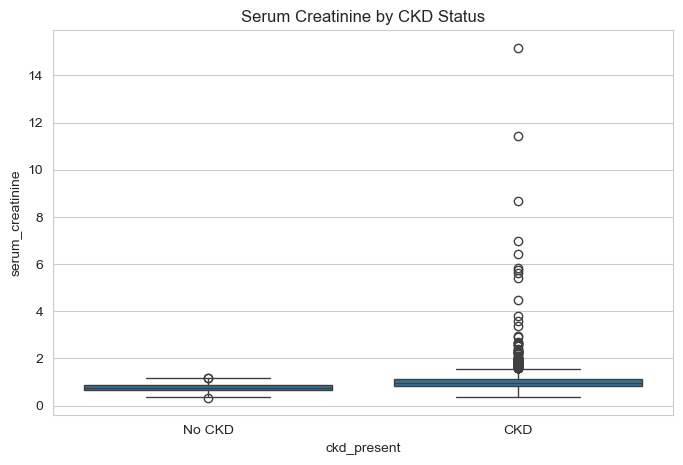

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="ckd_present",
    y="serum_creatinine"
)

plt.xticks([0,1],["No CKD","CKD"])

plt.title("Serum Creatinine by CKD Status")

plt.show()

## Data Cleaning

In [38]:
# Remove Unnecessary Columns

columns_to_drop = [
    "participant_id",
    "ckd_stage"
]

df = df.drop(columns=columns_to_drop)

print("Remaining Features:", df.shape[1])
df.head()

Remaining Features: 27


,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,...,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_present
0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,98.0,...,136.0,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,0
1,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,84.0,...,64.0,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,0
2,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,79.0,...,157.0,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,0
3,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,NaN,...,208.0,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,1
4,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,NaN,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,1


In [39]:
# Drop Features with excessive missing values

high_missing_columns = [
    "insulin_use",
    "diabetes_pills",
    "current_smoker"
]

df = df.drop(columns=high_missing_columns)

print(df.shape)

(11933, 24)


In [40]:
# Separate features and target

X = df.drop("ckd_present", axis=1)
y = df["ckd_present"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (11933, 23)
Target Shape: (11933,)


In [41]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical Features")
print(numerical_columns)

print("\nCategorical Features")
print(categorical_columns)

Numerical Features
['age', 'education_level', 'poverty_income_ratio', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic', 'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'diabetes_diagnosed', 'ever_smoked', 'egfr']

Categorical Features
['gender', 'ethnicity']


In [42]:
for column in categorical_columns:
    le = LabelEncoder()
    le.fit(X[column].astype(str))

    print(f"\n{column}")
    print(dict(zip(le.classes_, le.transform(le.classes_))))


gender
{'Female': np.int64(0), 'Male': np.int64(1)}

ethnicity
{'Mexican American': np.int64(0), 'Non-Hispanic Asian': np.int64(1), 'Non-Hispanic Black': np.int64(2), 'Non-Hispanic White': np.int64(3), 'Other Hispanic': np.int64(4), 'Other/Multiracial': np.int64(5)}


In [43]:
label_encoder = LabelEncoder()

# Encode each categorical column
for column in categorical_columns:
    X[column] = label_encoder.fit_transform(X[column].astype(str))

In [44]:
# Check the first five rows
X.head()

,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,...,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,ever_smoked,egfr
0,43.0,1,1,5.0,5.00,27.0,86.9,179.5,135.0,98.0,...,3.7,24.0,9.6,5.1,136.0,23.12,17.00,2.0,1.0,112.61
1,66.0,1,3,5.0,5.00,33.5,101.8,174.2,121.0,84.0,...,3.2,25.0,9.4,8.5,64.0,4.25,6.64,2.0,1.0,97.98
2,44.0,0,4,3.0,1.41,29.7,69.4,152.9,111.0,79.0,...,3.8,25.0,9.4,4.4,157.0,12.43,7.92,1.0,2.0,111.69
3,5.0,0,5,NaN,1.53,23.8,34.3,120.1,NaN,NaN,...,NaN,NaN,NaN,NaN,208.0,16.12,7.75,2.0,NaN,NaN
4,2.0,1,3,NaN,3.60,NaN,13.6,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN


In [45]:
# Check data types
X.dtypes

age                         float64
gender                        int64
ethnicity                     int64
education_level             float64
poverty_income_ratio        float64
bmi                         float64
weight_kg                   float64
height_cm                   float64
bp_systolic                 float64
bp_diastolic                float64
serum_creatinine            float64
blood_urea_nitrogen         float64
albumin_serum               float64
phosphorus                  float64
bicarbonate                 float64
calcium                     float64
uric_acid                   float64
urine_creatinine            float64
urine_albumin               float64
albumin_creatinine_ratio    float64
diabetes_diagnosed          float64
ever_smoked                 float64
egfr                        float64
dtype: object

In [46]:
# Missing Values Before Imputation

print("Missing Values Before Imputation")
print(X.isnull().sum().sort_values(ascending=False))

Missing Values Before Imputation
phosphorus                  5611
bicarbonate                 5608
serum_creatinine            5607
blood_urea_nitrogen         5607
egfr                        5607
uric_acid                   5604
calcium                     5571
albumin_serum               5567
bp_systolic                 4416
bp_diastolic                4416
education_level             4139
ever_smoked                 3798
albumin_creatinine_ratio    3780
urine_albumin               3780
urine_creatinine            3779
bmi                         3462
height_cm                   3434
weight_kg                   3179
poverty_income_ratio        2041
diabetes_diagnosed           193
gender                         0
ethnicity                      0
age                            0
dtype: int64


In [47]:
# Identify numerical and categorical columns

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = X.select_dtypes(include=["object"]).columns

print("Numerical Columns:", len(numerical_columns))
print("Categorical Columns:", len(categorical_columns))

Numerical Columns: 23
Categorical Columns: 0


In [48]:
# Check original values for diabetes and smoking

print("Diabetes Diagnosed values:")
print(X["diabetes_diagnosed"].unique())
print(X["diabetes_diagnosed"].value_counts(dropna=False))

print("\nEver Smoked values:")
print(X["ever_smoked"].unique())
print(X["ever_smoked"].value_counts(dropna=False))

Diabetes Diagnosed values:
[ 2.  1.  3. nan  9.]
diabetes_diagnosed
2.0    10371
1.0     1081
3.0      284
NaN      193
9.0        4
Name: count, dtype: int64

Ever Smoked values:
[ 1.  2. nan  9.  7.]
ever_smoked
2.0    4878
NaN    3798
1.0    3243
9.0       7
7.0       7
Name: count, dtype: int64


## Train-Test Split

Performed **before** imputation, outlier capping, scaling, and feature selection. Every one of those steps below is fit on `X_train`/`y_train` only and merely *applied* to `X_test`, so no information from the test set leaks into the fitted parameters (medians, IQR bounds, scaler mean/std, or the Boruta feature ranking).

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels :", y_test.shape)


Training Set: (9546, 23)
Testing Set : (2387, 23)
Training Labels: (9546,)
Testing Labels : (2387,)


In [50]:
# Median Imputer — fit on the TRAINING set only, then applied to both splits
median_imputer = SimpleImputer(strategy="median")

X_train[numerical_columns] = median_imputer.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = median_imputer.transform(X_test[numerical_columns])

joblib.dump(median_imputer, "median_imputer.pkl")


['median_imputer.pkl']

In [51]:
print("Remaining Missing Values (Train):", X_train.isnull().sum().sum())
print("Remaining Missing Values (Test):", X_test.isnull().sum().sum())


Remaining Missing Values (Train): 0
Remaining Missing Values (Test): 0


In [52]:
missing_after = pd.DataFrame({
    "Missing Values": X_train.isnull().sum()
})

missing_after[missing_after["Missing Values"] > 0]


,Missing Values


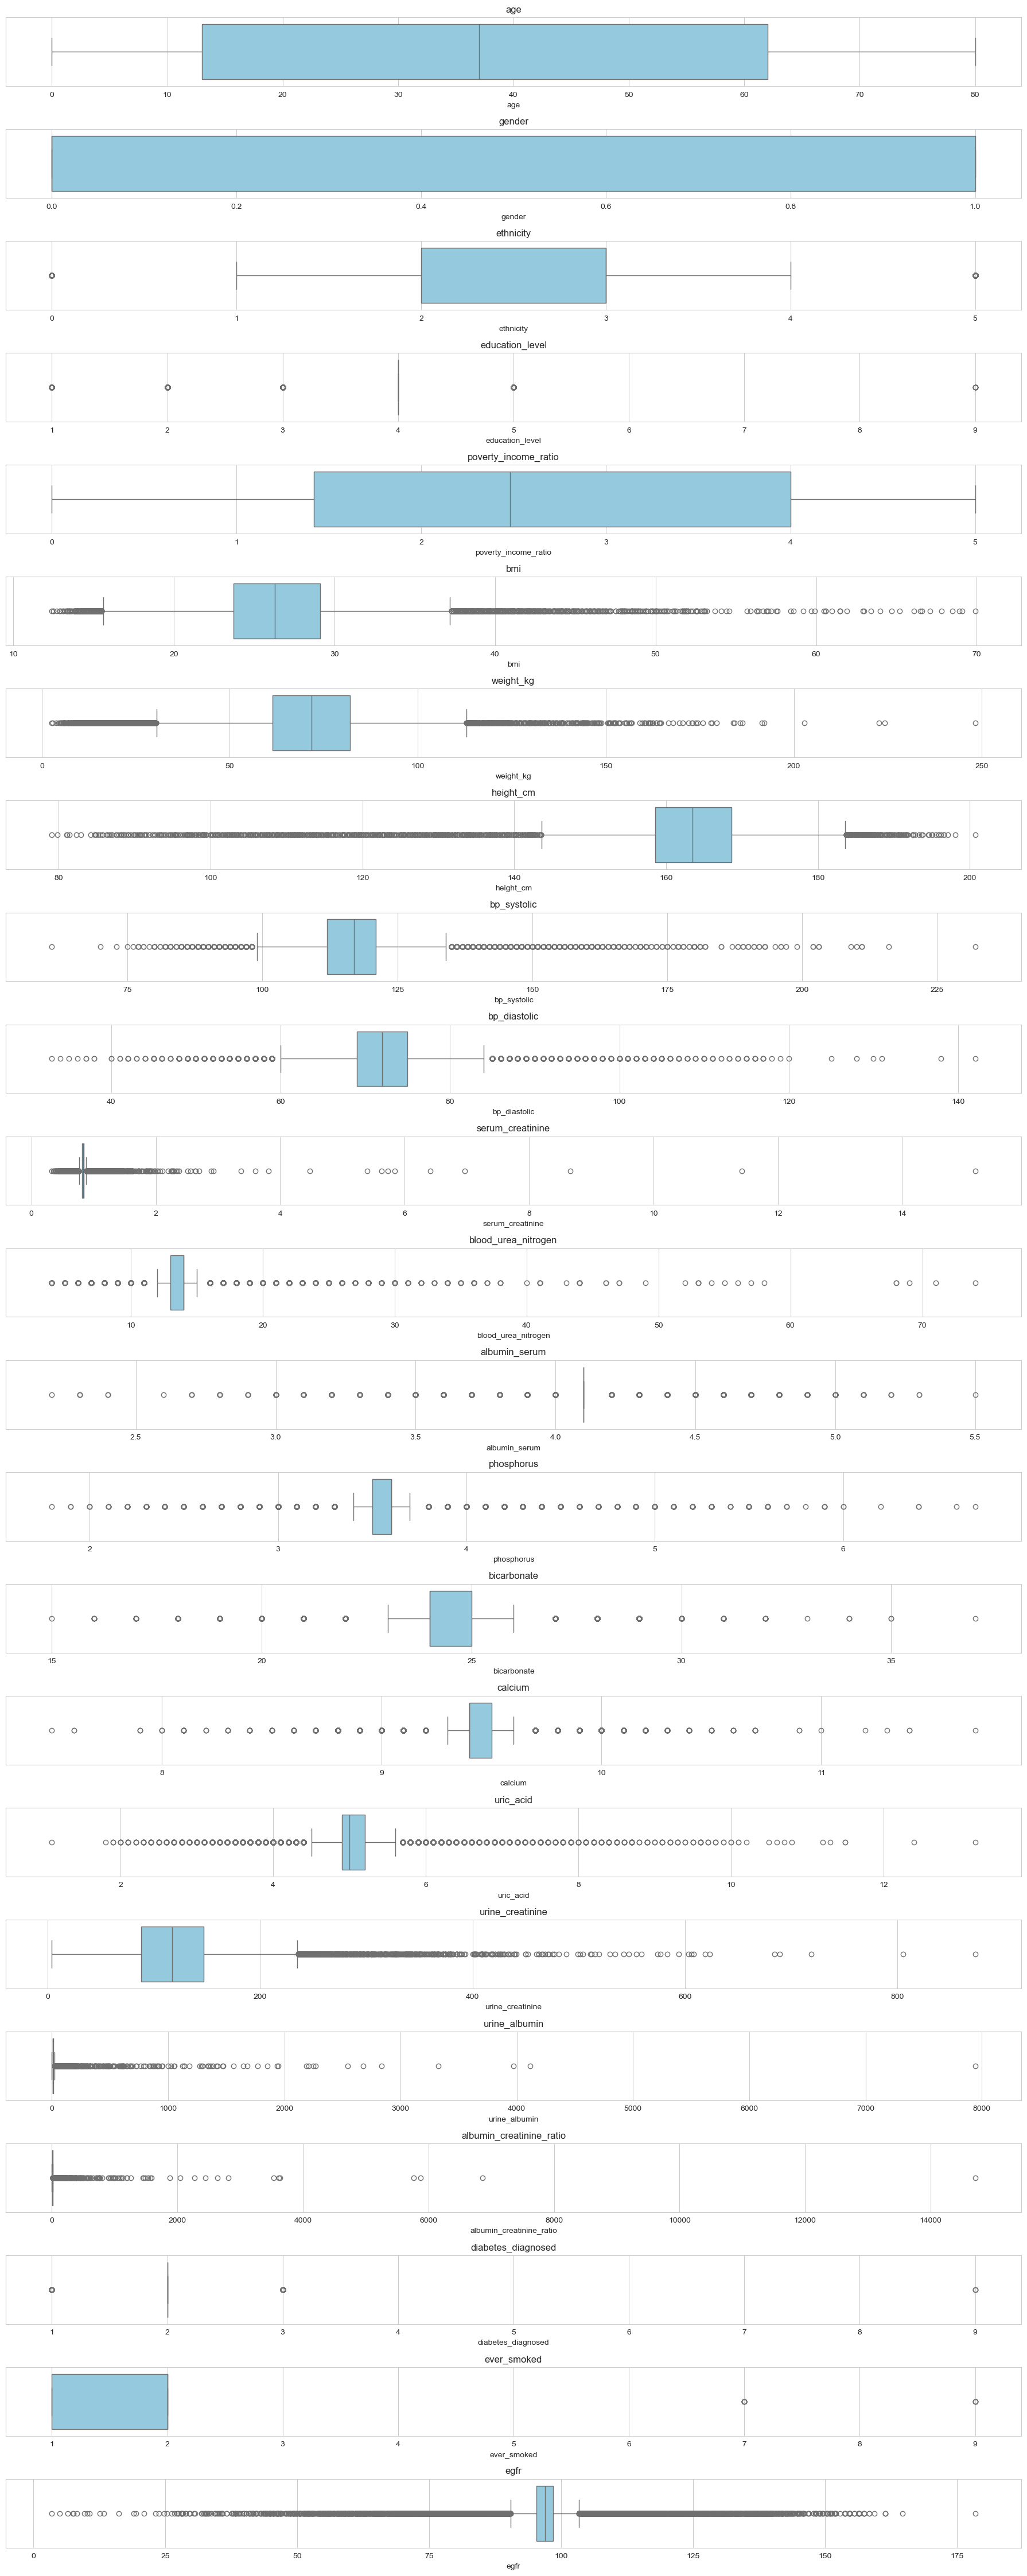

In [53]:
# Boxplots for Numerical Features (training set only)

numerical_columns = X_train.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18, 45))

for i, column in enumerate(numerical_columns):

    plt.subplot(len(numerical_columns), 1, i + 1)

    sns.boxplot(x=X_train[column], color="skyblue")

    plt.title(column)

plt.tight_layout()

plt.show()


In [54]:
# Count Outliers Using IQR (training set only)

outlier_summary = {}

for column in numerical_columns:

    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = X_train[(X_train[column] < lower) | (X_train[column] > upper)]

    outlier_summary[column] = len(outliers)

outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=["Feature", "Number of Outliers"]
)

outlier_df.sort_values(
    by="Number of Outliers",
    ascending=False
)


,Feature,Number of Outliers
12,albumin_serum,4479
3,education_level,4348
10,serum_creatinine,3888
22,egfr,3838
13,phosphorus,3629
16,uric_acid,3379
11,blood_urea_nitrogen,3285
15,calcium,2924
14,bicarbonate,1977
8,bp_systolic,1660


In [55]:
continuous_columns = [
    'age',
    'poverty_income_ratio',
    'bmi',
    'weight_kg',
    'height_cm',
    'bp_systolic',
    'bp_diastolic',
    'serum_creatinine',
    'blood_urea_nitrogen',
    'albumin_serum',
    'phosphorus',
    'bicarbonate',
    'calcium',
    'uric_acid',
    'urine_creatinine',
    'urine_albumin',
    'albumin_creatinine_ratio',
    'egfr'
]

iqr_bounds = {}

X_train_capped = X_train.copy()
X_test_capped = X_test.copy()

for column in continuous_columns:

    # Bounds computed from the TRAINING data only
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_bounds[column] = {
        "lower": lower,
        "upper": upper
    }

    X_train_capped[column] = X_train_capped[column].clip(lower=lower, upper=upper)
    X_test_capped[column] = X_test_capped[column].clip(lower=lower, upper=upper)

X_train_capped.describe().T


,count,mean,std,min,25%,50%,75%,max
age,9546.0,38.304735,2.561433e+01,5.397605e-79,13.0000,37.000,62.00,80.00000
gender,9546.0,0.469516,4.990960e-01,0.000000e+00,0.0000,0.000,1.00,1.00000
ethnicity,9546.0,2.743872,1.249191e+00,0.000000e+00,2.0000,3.000,3.00,5.00000
education_level,9546.0,3.870207,9.402354e-01,1.000000e+00,4.0000,4.000,4.00,9.00000
poverty_income_ratio,9546.0,2.664732,1.521359e+00,5.397605e-79,1.4200,2.480,4.00,5.00000
bmi,9546.0,26.514278,5.538620e+00,1.560000e+01,23.7000,26.300,29.10,37.20000
weight_kg,9546.0,71.046781,2.128531e+01,3.050000e+01,61.4000,71.700,82.00,112.90000
height_cm,9546.0,163.097287,1.013273e+01,1.436000e+02,158.6000,163.500,168.60,183.60000
bp_systolic,9546.0,117.154620,9.919713e+00,9.850000e+01,112.0000,117.000,121.00,134.50000
bp_diastolic,9546.0,72.030693,6.718886e+00,6.000000e+01,69.0000,72.000,75.00,84.00000


In [56]:
joblib.dump(iqr_bounds, "iqr_bounds.pkl")


['iqr_bounds.pkl']

In [57]:
# Initialize StandardScaler — fit on the TRAINING set only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_capped)
X_test_scaled = scaler.transform(X_test_capped)


In [58]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_capped.columns,
    index=X_train_capped.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_capped.columns,
    index=X_test_capped.index
)

X_train_scaled.head()


,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,...,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,ever_smoked,egfr
4102,-0.402325,-0.940782,0.205046,0.138050,-0.121432,-0.038690,0.030690,0.039746,-0.015588,-0.004568,...,0.164362,-0.228656,-0.173601,-0.064133,-0.079086,-0.185623,-0.223544,0.185188,0.541901,0.007118
8669,-0.129026,-0.940782,-2.196634,-0.925569,-0.246327,-0.453978,-0.486125,-0.414252,1.194188,1.186167,...,-1.727366,-1.570784,-1.384411,-1.492417,-1.827564,-1.906298,-1.772212,0.185188,-1.514952,1.483876
7644,1.627896,1.062945,0.205046,-0.925569,1.535068,-0.363698,0.134053,1.036568,-0.015588,-0.004568,...,-1.349020,1.560849,-1.384411,-1.492417,-0.149025,1.832807,1.868921,0.185188,-1.514952,-1.516080
6074,-0.089983,-0.940782,-1.396074,1.201669,1.535068,0.015478,-0.373365,-0.897859,-1.880659,-0.004568,...,1.299399,0.666096,-1.384411,-0.583509,0.742699,0.396532,-0.336054,0.185188,0.541901,-1.516080
6060,-1.027008,1.062945,0.205046,0.138050,-0.121432,-0.038690,0.030690,0.039746,-0.015588,-0.004568,...,0.164362,-0.228656,-0.173601,-0.064133,-0.079086,-0.185623,-0.223544,0.185188,0.541901,0.007118


In [59]:
# Summary statistics after scaling (training set)
X_train_scaled.describe().round(2)


,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,...,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,ever_smoked,egfr
count,9546.00,9546.00,9546.00,9546.00,9546.00,9546.00,9546.00,9546.00,9546.00,9546.00,...,9546.00,9546.00,9546.00,9546.00,9546.00,9546.00,9546.00,9546.00,9546.00,9546.00
mean,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,...,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.50,-0.94,-2.20,-3.05,-1.75,-1.97,-1.91,-1.92,-1.88,-1.79,...,-1.73,-1.57,-1.38,-1.49,-2.05,-1.91,-2.03,-2.63,-1.51,-1.52
25%,-0.99,-0.94,-0.60,0.14,-0.82,-0.51,-0.45,-0.44,-0.52,-0.45,...,-0.59,-0.23,-0.17,-0.32,-0.58,-0.58,-0.59,0.19,-1.51,-0.39
50%,-0.05,-0.94,0.21,0.14,-0.12,-0.04,0.03,0.04,-0.02,-0.00,...,0.16,-0.23,-0.17,-0.06,-0.08,-0.19,-0.22,0.19,0.54,0.01
75%,0.93,1.06,0.21,0.14,0.88,0.47,0.51,0.54,0.39,0.44,...,0.16,0.67,0.63,0.46,0.45,0.39,0.40,0.19,0.54,0.36
max,1.63,1.06,1.81,5.46,1.54,1.93,1.97,2.02,1.75,1.78,...,1.30,2.01,1.84,1.62,1.99,1.83,1.87,19.89,14.94,1.48


In [60]:
comparison = pd.DataFrame({
    "Original Mean": X_train_capped.mean(),
    "Scaled Mean": X_train_scaled.mean(),
    "Original Std": X_train_capped.std(),
    "Scaled Std": X_train_scaled.std()
})

comparison.round(2)


,Original Mean,Scaled Mean,Original Std,Scaled Std
age,38.30,-0.0,25.61,1.0
gender,0.47,0.0,0.50,1.0
ethnicity,2.74,0.0,1.25,1.0
education_level,3.87,-0.0,0.94,1.0
poverty_income_ratio,2.66,0.0,1.52,1.0
bmi,26.51,-0.0,5.54,1.0
weight_kg,71.05,-0.0,21.29,1.0
height_cm,163.10,0.0,10.13,1.0
bp_systolic,117.15,0.0,9.92,1.0
bp_diastolic,72.03,0.0,6.72,1.0


## Boruta-Feature Selection

In [61]:
# Random Forest for Boruta

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)


In [62]:
# Hyperparameters made explicit for reproducibility:
# perc  = percentile of the shadow-feature max importance used as the
#         comparison threshold (100 = strictest / default)
# alpha = significance level for the two-step Bonferroni/Holm correction
boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    perc=100,
    alpha=0.05,
    max_iter=100,
    random_state=42,
    verbose=2
)


In [63]:
# Fit on the TRAINING data only
boruta_selector.fit(
    X_train_scaled.values,
    y_train.values
)


Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	23
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	16
Tentative: 	1
Rejected: 	6
Iteration: 	9 / 100
Confirmed: 	16
Tentative: 	1
Rejected: 	6
Iteration: 	10 / 100
Confirmed: 	16
Tentative: 	1
Rejected: 	6
Iteration: 	11 / 100
Confirmed: 	16
Tentative: 	1
Rejected: 	6
Iteration: 	12 / 100
Confirmed: 	16
Tentative: 	1
Rejected: 	6
Iteration: 	13 / 100
Confirmed: 	16
Tentative: 	1
Rejected: 	6
Iteration: 	14 / 100
Confirmed: 	16
Tentative: 	1
Rejected: 	6
Iteration: 	15 / 100
Confirmed: 	16
Tentative: 	1
Rejected: 	6
Iteration: 	16 / 100
Confirmed: 	16
Tentative: 	1
Rejected: 	6
I

BorutaPy(estimator=RandomForestClassifier(class_weight='balanced',
                                          n_estimators=58, n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x1CEDF497540),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x1CEDF497540, verbose=2)

In [64]:
selected_features = X_train_scaled.columns[
    boruta_selector.support_
]

print("Selected Features:")
print(selected_features.tolist())


Selected Features:
['age', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic', 'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'egfr']


In [65]:
print(f"Total Selected Features: {len(selected_features)}")


Total Selected Features: 16


In [66]:
rejected_features = X_train_scaled.columns[
    ~boruta_selector.support_
]

print("Rejected Features:")
print(rejected_features.tolist())


Rejected Features:
['gender', 'ethnicity', 'education_level', 'poverty_income_ratio', 'albumin_serum', 'diabetes_diagnosed', 'ever_smoked']


In [67]:
feature_ranking = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Ranking": boruta_selector.ranking_
})

feature_ranking = feature_ranking.sort_values("Ranking")

feature_ranking


,Feature,Ranking
0,age,1
7,height_cm,1
6,weight_kg,1
5,bmi,1
11,blood_urea_nitrogen,1
10,serum_creatinine,1
9,bp_diastolic,1
8,bp_systolic,1
13,phosphorus,1
14,bicarbonate,1


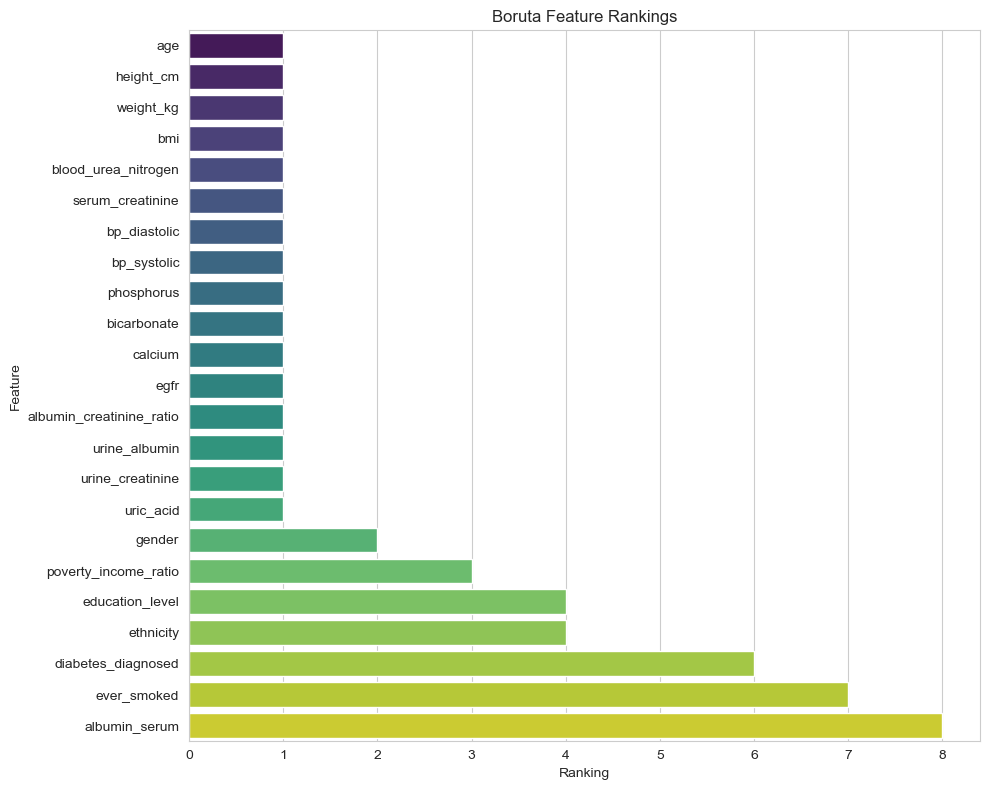

In [68]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_ranking,
    x="Ranking",
    y="Feature",
    palette="viridis"
)

plt.title("Boruta Feature Rankings")

plt.tight_layout()

plt.show()


In [69]:
# Apply the Boruta-selected features to BOTH splits (fit happened on train only)
X_train = X_train_scaled[selected_features]
X_test = X_test_scaled[selected_features]

print("Scaled Shape (train):", X_train_scaled.shape)
print("Selected Shape (train):", X_train.shape)
print("Selected Shape (test):", X_test.shape)


Scaled Shape (train): (9546, 23)
Selected Shape (train): (9546, 16)
Selected Shape (test): (2387, 16)


In [70]:
joblib.dump(
    selected_features.tolist(),
    "selected_features.pkl"
)

print("Selected features saved successfully.")


Selected features saved successfully.


In [71]:
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [72]:
# Model Evaluation Function
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities (if supported)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Specificity
    specificity = tn / (tn + fp)

    # Metrics
    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Specificity": specificity,
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    return results

## Model Training & Hyperparameter Tuning

Every model below — not just XGBoost — is tuned with `GridSearchCV` (5-fold, scored on ROC-AUC) so the comparison across models is on equal footing. `GaussianNB` has no hyperparameters worth grid-searching for this feature set, so it is fit directly.

In [73]:
param_grids = {
    "Logistic Regression": {
        "estimator": LogisticRegression(random_state=42, max_iter=1000),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["lbfgs"]
        }
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [3, 5, 7, 10, None],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5]
        }
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9, 11],
            "weights": ["uniform", "distance"]
        }
    },
    "SVM": {
        "estimator": SVC(probability=True, random_state=42),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        }
    },
    "XGBoost": {
        "estimator": XGBClassifier(random_state=42, eval_metric="logloss"),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    }
}


In [74]:
trained_models = {}
best_params_summary = {}

for name, cfg in param_grids.items():

    print(f"Tuning {name}...")

    search = GridSearchCV(
        estimator=cfg["estimator"],
        param_grid=cfg["params"],
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    trained_models[name] = search.best_estimator_
    best_params_summary[name] = search.best_params_

    print(f"  Best Params: {search.best_params_}")
    print(f"  Best CV ROC-AUC: {search.best_score_:.4f}\n")

# Naive Bayes has no meaningful hyperparameters to tune here — fit directly
trained_models["Naive Bayes"] = GaussianNB().fit(X_train, y_train)

print("All models tuned and trained successfully!")


Tuning Logistic Regression...
  Best Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Best CV ROC-AUC: 0.9215

Tuning Decision Tree...
  Best Params: {'max_depth': 5, 'min_samples_split': 2}
  Best CV ROC-AUC: 0.9964

Tuning Random Forest...
  Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
  Best CV ROC-AUC: 0.9980

Tuning KNN...
  Best Params: {'n_neighbors': 11, 'weights': 'distance'}
  Best CV ROC-AUC: 0.9775

Tuning SVM...
  Best Params: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
  Best CV ROC-AUC: 0.9827

Tuning XGBoost...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
  Best CV ROC-AUC: 0.9982

All models tuned and trained successfully!


In [75]:
results = []

for name, model in trained_models.items():

    metrics = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1-Score",
        "ROC-AUC"
    ]
]

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df.round(4)


,Model,Accuracy,Precision,Recall,Specificity,F1-Score,ROC-AUC
5,XGBoost,0.9807,0.9833,0.9892,0.9611,0.9863,0.9985
2,Random Forest,0.9791,0.9815,0.9886,0.9569,0.9851,0.9985
1,Decision Tree,0.9778,0.9844,0.9838,0.9638,0.9841,0.9957
4,SVM,0.9581,0.9585,0.9826,0.9013,0.9704,0.9835
3,KNN,0.9393,0.9456,0.9688,0.8707,0.9571,0.9811
6,Naive Bayes,0.8827,0.9572,0.8711,0.9096,0.9121,0.9603
0,Logistic Regression,0.9150,0.9145,0.9688,0.7900,0.9409,0.9299


In [76]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

joblib.dump(best_model, "best_model.pkl")

print(f"{best_model_name} saved successfully!")


XGBoost saved successfully!


In [77]:
# Single source of truth for the tuned XGBoost model — every cell below
# (confusion matrix, ROC/PR curves, feature importance, SHAP, final save)
# references this exact object, so results/plots stay consistent with the
# reported metrics.
best_xgb = trained_models["XGBoost"]

print("Best XGBoost Params:", best_params_summary["XGBoost"])


Best XGBoost Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}


## Model Evaluation

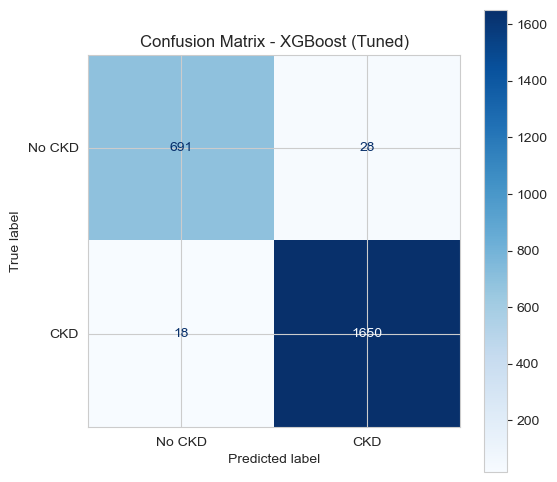

TN=691, FP=28, FN=18, TP=1650


,Predicted: No CKD,Predicted: CKD
Actual: No CKD,691,28
Actual: CKD,18,1650


In [78]:
from sklearn.metrics import ConfusionMatrixDisplay

# Use the tuned XGBoost model
xgb_model = best_xgb

# Predictions
y_pred = xgb_model.predict(X_test)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    display_labels=["No CKD", "CKD"],
    ax=ax
)

plt.title("Confusion Matrix - XGBoost (Tuned)")
plt.show()

# Explicit labeled table, for direct use in the paper
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

confusion_table = pd.DataFrame(
    {
        "Predicted: No CKD": [tn, fn],
        "Predicted: CKD": [fp, tp]
    },
    index=["Actual: No CKD", "Actual: CKD"]
)

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
confusion_table


In [79]:
# Classification report

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["No CKD", "CKD"]
))


              precision    recall  f1-score   support

      No CKD       0.97      0.96      0.97       719
         CKD       0.98      0.99      0.99      1668

    accuracy                           0.98      2387
   macro avg       0.98      0.98      0.98      2387
weighted avg       0.98      0.98      0.98      2387



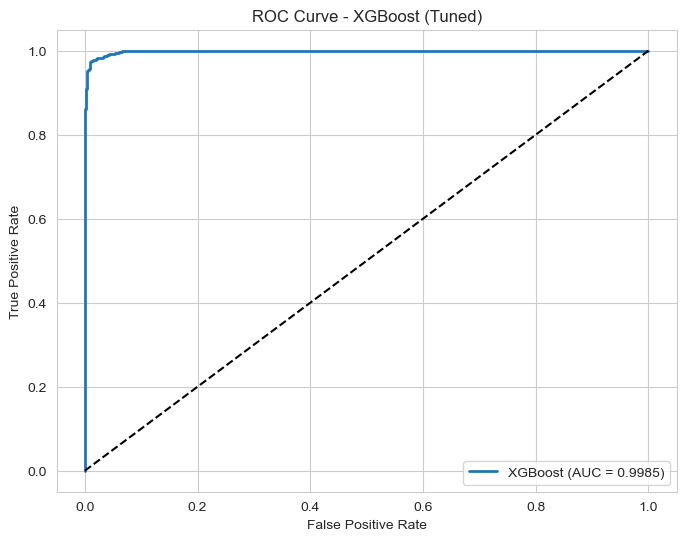

In [80]:
from sklearn.metrics import roc_curve, auc

# Prediction probabilities
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.4f})",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost (Tuned)")
plt.legend()

plt.show()


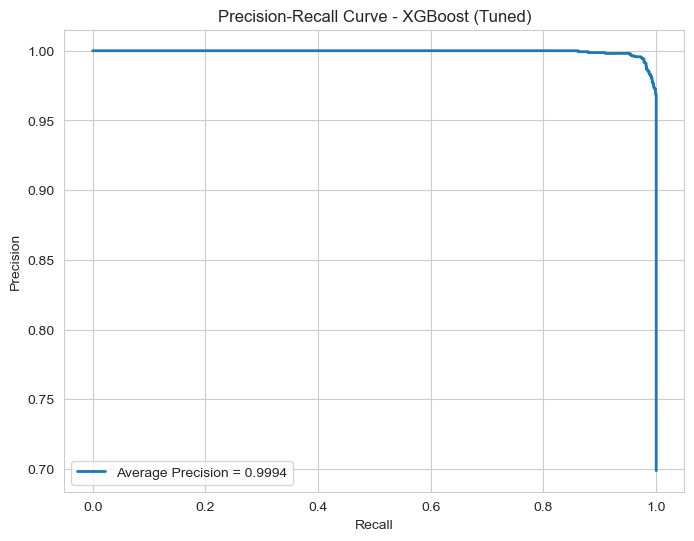

In [81]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Predict probabilities
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Precision-Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Average Precision Score
average_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Average Precision = {average_precision:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost (Tuned)")

plt.legend()

plt.grid(True)

plt.show()


In [82]:
# 10-fold stratified CV on the TRAINING set
# (kept separate from the held-out test set used above; combining
# train+test here would reintroduce the leakage the split was fixing)
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross Validation Scores")
print(scores)

print("\nMean Accuracy:", scores.mean())

print("Standard Deviation:", scores.std())


Cross Validation Scores
[0.98010471 0.98638743 0.9895288  0.98219895 0.98324607 0.98743455
 0.96960168 0.98322851 0.98113208 0.98008386]

Mean Accuracy: 0.9822946645153502
Standard Deviation: 0.005190716781818197


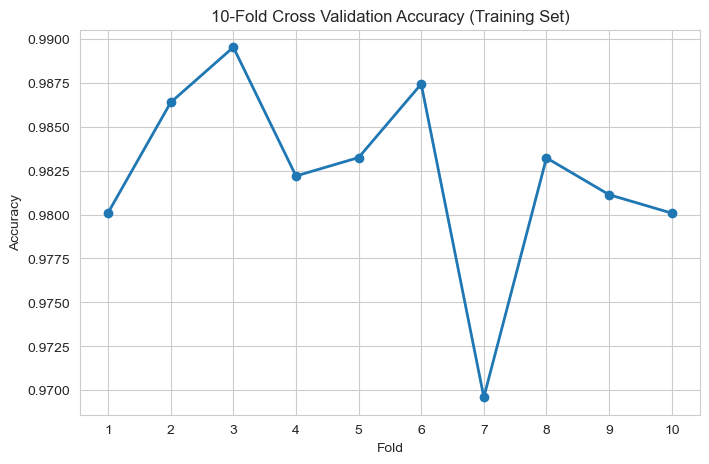

In [83]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    scores,
    marker="o",
    linewidth=2
)

plt.xticks(range(1,11))

plt.xlabel("Fold")

plt.ylabel("Accuracy")

plt.title("10-Fold Cross Validation Accuracy (Training Set)")

plt.grid(True)

plt.show()


## Note on External Validation (Limitation)

Everything above is evaluated with an internal train/test split and stratified k-fold cross-validation on a single NHANES extract. No external clinical dataset (e.g. MIMIC-III/IV, eICU, or hospital EHR data) has been used to test out-of-distribution generalizability. This notebook does not resolve that gap — it needs a second, independently sourced dataset, which should either be added as a follow-up validation step or explicitly listed as a limitation in the manuscript.

In [84]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)


,Feature,Importance
15,egfr,0.299434
7,blood_urea_nitrogen,0.213360
6,serum_creatinine,0.186142
11,uric_acid,0.081687
14,albumin_creatinine_ratio,0.057452
0,age,0.043196
3,height_cm,0.024641
9,bicarbonate,0.021751
13,urine_albumin,0.021705
8,phosphorus,0.013088


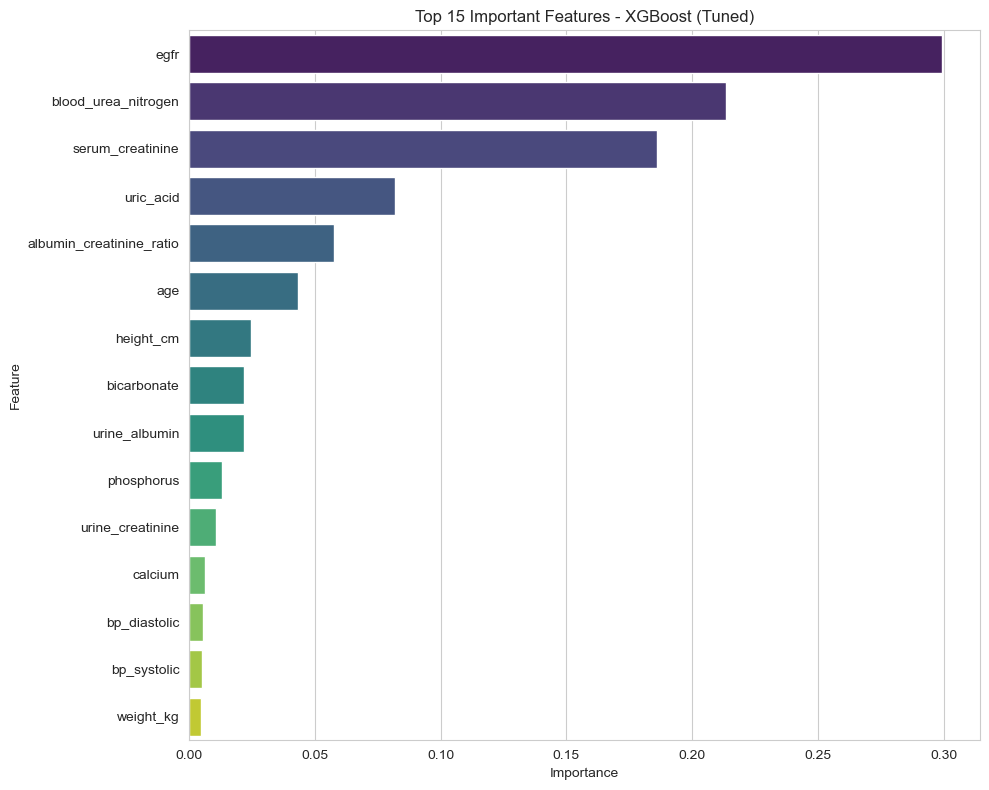

In [85]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Important Features - XGBoost (Tuned)")

plt.tight_layout()

plt.show()


## SHAP Explainability

In [86]:
explainer = shap.TreeExplainer(best_xgb)


In [87]:
shap_values = explainer.shap_values(X_test)


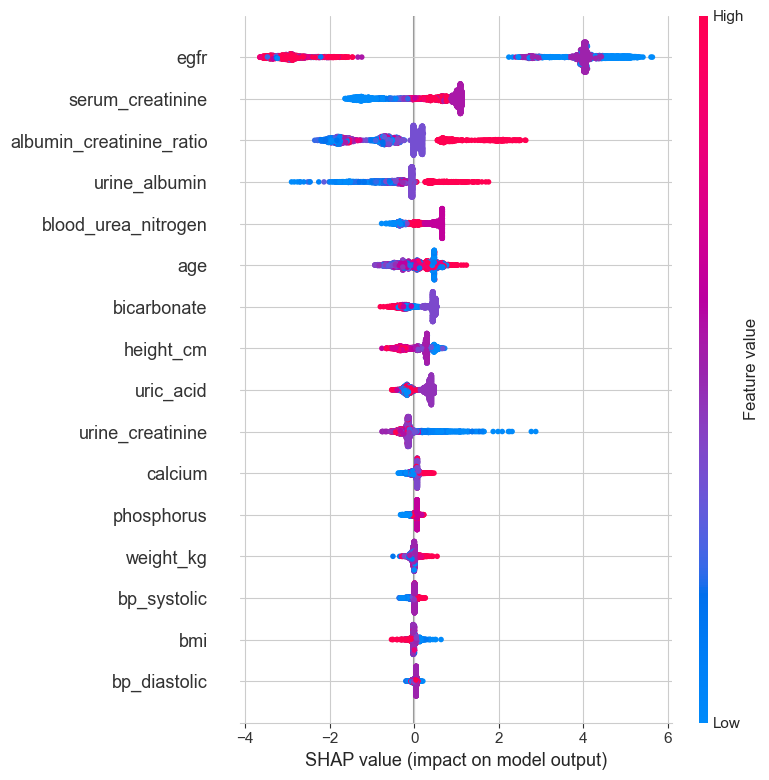

In [88]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.show()


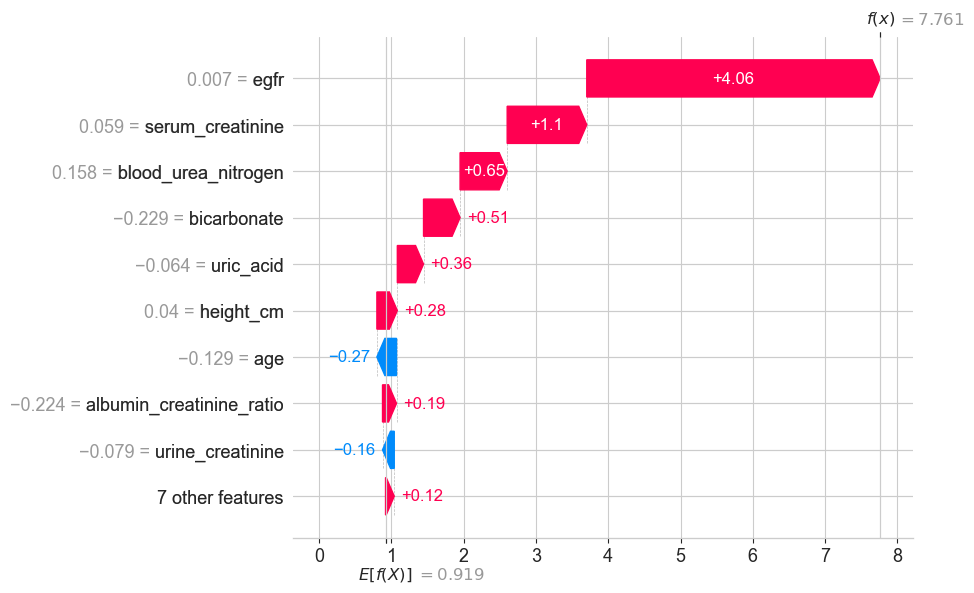

In [89]:
# Explain the first test sample
shap.plots.waterfall(
    explainer(X_test.iloc[[0]])[0]
)


## Ablation: Performance Without Direct Diagnostic Features

eGFR (and, to a lesser extent, serum creatinine) directly enters the clinical definition of CKD, so a model leaning on them mostly recovers the diagnostic formula rather than learning independent risk patterns. This retrains XGBoost with both features removed, to see how much performance depends on them versus the remaining demographic/lab predictors.

In [90]:
ablation_features = [f for f in selected_features if f not in ["egfr", "serum_creatinine"]]

X_train_ablation = X_train[ablation_features]
X_test_ablation = X_test[ablation_features]

ablation_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid=param_grids["XGBoost"]["params"],
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

ablation_search.fit(X_train_ablation, y_train)
ablation_model = ablation_search.best_estimator_

ablation_metrics = evaluate_model(
    ablation_model,
    X_train_ablation,
    X_test_ablation,
    y_train,
    y_test
)

full_metrics = evaluate_model(best_xgb, X_train, X_test, y_train, y_test)

ablation_comparison = pd.DataFrame(
    [full_metrics, ablation_metrics],
    index=["With eGFR & Serum Creatinine", "Without eGFR & Serum Creatinine"]
)

ablation_comparison.round(4)


,Accuracy,Precision,Recall,Specificity,F1-Score,ROC-AUC
With eGFR & Serum Creatinine,0.9807,0.9833,0.9892,0.9611,0.9863,0.9985
Without eGFR & Serum Creatinine,0.8995,0.9270,0.9293,0.8303,0.9281,0.9635


In [91]:
patient_data = {
    "age": 40,
    "gender": 1,
    "ethnicity": 3,
    "education_level": 3,
    "poverty_income_ratio": 2.0,
    "bmi": 22.0,
    "weight_kg": 70.0,
    "height_cm": 170.0,
    "bp_systolic": 120.0,
    "bp_diastolic": 80.0,
    "serum_creatinine": 1.0,
    "blood_urea_nitrogen": 15.0,
    "albumin_serum": 4.0,
    "phosphorus": 3.5,
    "bicarbonate": 24.0,
    "calcium": 9.5,
    "uric_acid": 5.0,
    "urine_creatinine": 100.0,
    "urine_albumin": 20.0,
    "albumin_creatinine_ratio": 30.0,
    "diabetes_diagnosed": 2,
    "ever_smoked": 2,
    "egfr": 95.0
}

In [92]:
input_data = pd.DataFrame([patient_data])

In [93]:
scaler_features = list(scaler.feature_names_in_)

input_data = input_data[scaler_features]

for column, bounds in iqr_bounds.items():
    if column in input_data.columns:
        input_data[column] = input_data[column].clip(
            lower=bounds["lower"],
            upper=bounds["upper"]
        )

In [94]:
print(input_data.T)

                                0
age                        40.000
gender                      1.000
ethnicity                   3.000
education_level             3.000
poverty_income_ratio        2.000
bmi                        22.000
weight_kg                  70.000
height_cm                 170.000
bp_systolic               120.000
bp_diastolic               80.000
serum_creatinine            0.885
blood_urea_nitrogen        15.000
albumin_serum               4.100
phosphorus                  3.500
bicarbonate                24.000
calcium                     9.500
uric_acid                   5.000
urine_creatinine          100.000
urine_albumin              20.000
albumin_creatinine_ratio   17.745
diabetes_diagnosed          2.000
ever_smoked                 2.000
egfr                       95.000


In [95]:
input_scaled = scaler.transform(input_data)

input_scaled = pd.DataFrame(
    input_scaled,
    columns=scaler_features
)

model_input = input_scaled[selected_features]

prediction = best_xgb.predict(model_input)[0]

probabilities = best_xgb.predict_proba(model_input)[0]

print("Prediction:", prediction)
print(f"No CKD Probability: {probabilities[0] * 100:.2f}%")
print(f"CKD Probability: {probabilities[1] * 100:.2f}%")


Prediction: 0
No CKD Probability: 83.05%
CKD Probability: 16.95%


In [96]:
print(list(iqr_bounds.keys()))


['age', 'poverty_income_ratio', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic', 'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'egfr']


In [97]:
print(selected_features)


Index(['age', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic', 'bp_diastolic',
       'serum_creatinine', 'blood_urea_nitrogen', 'phosphorus', 'bicarbonate',
       'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin',
       'albumin_creatinine_ratio', 'egfr'],
      dtype='object')


In [98]:
import joblib

joblib.dump(best_xgb, "best_xgboost_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(selected_features, "selected_features.pkl")
joblib.dump(iqr_bounds, "iqr_bounds.pkl")

print("All files saved successfully.")


All files saved successfully.
